In [1]:
# Cell Block 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mtick
from mpl_toolkits.mplot3d import Axes3D  
import plotly.graph_objects as go
from scipy.optimize import brentq
from plotly.subplots import make_subplots
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# Tax Calculation

In [34]:
from marginal_taxes.tax_s import get_swiss_marginal_rate
from marginal_taxes.tax_g import get_german_marginal_rate
from marginal_taxes.tax_a import get_australia_marginal_rate

m_s = get_swiss_marginal_rate(81_456, "Zurich") # Swiss Average Salary: 81_456 CHF = 75_431 GBP

m_g = get_german_marginal_rate(55_608, joint=False) # German Average Salary: 55_608 EUR = 48_246 GBP

m_a = get_australia_marginal_rate(104_450) # Australia Average Salary: 104_520 AUD = 50_721 GBP

print(f"Swiss: {m_s:.2f}, German: {m_g:.2f}, Australia: {m_a:.2f}")



Swiss: 0.20, German: 0.37, Australia: 0.32


## Interest Rate Calculation

In [23]:
def r_to_quarter(rate):
    """Converts annual rate to effective quarterly rate."""
    return (1.0 + rate)**0.25 - 1.0

# Parameter Definitions


In [24]:
# Cell Block 2

# Model Parameters and Constants
# Default parameter values based on the paper, see p.12
DEFAULT_PARAMS = {
    'l': 0.5,       # loan-to-value ratio - LTV - p.5, eq.2
    'u': 0.5,       # μ (mu) - risk factor of investment p.5 eq3
    'p': 0.5,       # probability that investment generates a gain p.7 eq11/12
    's': 0.0,       # [-4%,+4%] average value of market's fluctuations p.7 eq13
    'E0': 30000,    # initial equity (in usd) p.6: 3.1
    'M0': 300000,   # initial mortgage (in usd) p.6: 3.1
    'pi_star': 3000,  # regular installment (in usd) p.6 eq14/15
    'q': 0.01,      # probability of skipping installment p.6 eq14/15

    #  Model 5 additions ("With r_b, τ_b, r_m, τ_m") 
    'rb': 0.0,      # per-period borrowing cost on LOC used for investing (r_b)
    'rm': 0.0,      # per-period mortgage interest (r_m)
    'tb': 0.0,      # τ_b: marginal tax shield on LOC interest
    'tm': 0.0       # τ_m: marginal tax shield on mortgage interest
}

# Constants for phase diagram (100 values from 0 to 1 and 100 from -0.04 to +0.04)
# maybe decrease nr. of sample points from 100 to 50 to increase speed
# span the (p, s) grid for the phase diagram:
P_RANGE = np.linspace(0.0, 1.0, 100)   # probability investment generates gain
S_RANGE = np.linspace(-0.04, 0.04, 100)  # house market fluctuations -4% to 4%
RB_RANGE = np.linspace(0.0, 0.1, 100) # Grid for borrowing cost on the y-axis (0% to 4%, 50 points to mirror S_RANGE)
RM_RANGE = np.linspace(0.0, 0.06, 100) # Grid for mortgage interest on the y-axis (0% to 4%, 50 points like RB/TB plots)
TB_RANGE = np.linspace(0.0, 0.50, 100) # Grid for borrowing-interest tax shield on the y-axis (0% to 50%, 50 points)
TM_RANGE = np.linspace(0.0, 0.50, 100) # Grid for mortgage interest tax shield on the y-axis (0% to 50%, 50 points)


print("Parameters defined:")
for key, value in DEFAULT_PARAMS.items():
    print(f"  {key}: {value}")


Parameters defined:
  l: 0.5
  u: 0.5
  p: 0.5
  s: 0.0
  E0: 30000
  M0: 300000
  pi_star: 3000
  q: 0.01
  rb: 0.0
  rm: 0.0
  tb: 0.0
  tm: 0.0


# Functions and Trajectories

## Math Functions (lambda 1&2, c1 - c4, A - F, Average E_t & M_t)

In [25]:
# Cell Block 3

# Math Functions

""" process:
1. compute eigenvalues λ₁ & λ₂ of the average-dynamics matrix Ā
   - Model 5 average matrix ("With Borrowing-Cost r_b, Tax Shield τ_b, Mortgage Interest r_m and Mortgage Interest Tax Shield τ_m"):
     Ā(5) = [[1 + s + ℓµ(2p−1) − ℓ(1−τ_b) r_b,   s + τ_m r_m],
              [−ℓµ(2p−1),                         1 + r_m]]
     Eigenvalues are the two roots of λ² − tr(Ā)λ + det(Ā) = 0.

2. compute c coefficients (same definitions as Base Model)
   - c1 = M0/E0, c2 = ⟨π⟩/E0, c3 = E0/M0, c4 = ⟨π⟩/M0

3. compute ABCDEF coefficients for the closed-form in NORMALIZED variables:
   ⟨E_t⟩/E0 = A λ₁^t + B λ₂^t + C
   ⟨M_t⟩/M0 = D λ₁^t + E λ₂^t + F
   We compute these generically from the eigendecomposition of the normalized system:
     y_t = [E_t/E0, M_t/M0]^T
     y_{t+1} = Ã y_t + b~,  with  Ã = S^{-1} Ā S,  b~ = S^{-1} b,  S = diag(E0, M0),  b=[⟨π⟩, −⟨π⟩]^T.
   Using Ã = UΛU⁻¹ and Σ_{k=0}^{t-1}Λ^k = (Λ^t−I)(Λ−I)⁻¹ we can rewrite components
   and read off A..F from (U,Λ,U⁻¹,b~,y₀) where y₀=[1,1]^T.
"""

def _average_matrix_model5(l, u, p, s, rb, rm, tb, tm):
    """
    Build the Model 5 average-dynamics matrix Ā(5).
    Ā(5) = [[1 + s + l*u*(2p-1) - l*(1 - tb)*rb,      s + tm*rm],
             [           -l*u*(2p-1),                 1 + rm   ]]
    """
    a11 = 1.0 + s + l * u * (2.0 * p - 1.0) - l * (1.0 - tb) * rb
    a12 = s + tm * rm
    a21 = - l * u * (2.0 * p - 1.0)
    a22 = 1.0 + rm
    return np.array([[a11, a12],
                     [a21, a22]], dtype=float)

def _normalized_system_model5(l, u, p, s, rb, rm, tb, tm, E0, M0, pi_avg):
    """
    Return (Ã, b~, y0) where
      y_t = [E_t/E0, M_t/M0]^T,  y_{t+1} = Ã y_t + b~,  y_0 = [1, 1]^T
    with  Ã = S^{-1} Ā S,  b~ = S^{-1} b,  S = diag(E0, M0).
    """
    Abar = _average_matrix_model5(l, u, p, s, rb, rm, tb, tm)
    S = np.diag([E0, M0])
    Sinv = np.linalg.inv(S)
    A_tilde = Sinv @ Abar @ S
    b_tilde = Sinv @ np.array([pi_avg, -pi_avg], dtype=float)
    y0 = np.array([1.0, 1.0], dtype=float)  # [E0/E0, M0/M0]
    return A_tilde, b_tilde, y0

def _eigendecomposition(l, u, p, s, rb, rm, tb, tm):
    """
    Helper: return ((λ1, λ2), U, U_inv) for Ā(5).
    """
    Abar = _average_matrix_model5(l, u, p, s, rb, rm, tb, tm)
    vals, U = np.linalg.eig(Abar)
    vals = np.real_if_close(vals, tol=1e-10)
    U = np.real_if_close(U, tol=1e-10)
    U_inv = np.linalg.inv(U)
    return (float(vals[0]), float(vals[1])), U.astype(float), U_inv.astype(float)

def compute_eigenvalues(l, u, p, s, rb=0.0, rm=0.0, tb=0.0, tm=0.0):
    """
    Compute eigenvalues λ1, λ2 of the Model 5 average matrix Ā(5).
    We return them in the same order as used by the shared eigendecomposition helper.
    """
    (lam1, lam2), _, _ = _eigendecomposition(l, u, p, s, rb, rm, tb, tm)
    return lam1, lam2

def compute_c_coefficients(E0, M0, pi_avg):
    """
    Compute c1, c2, c3, c4 coefficients
    c1 = M0/E0, c2 = pi_avg/E0, c3 = E0/M0, c4 = pi_avg/M0
    """
    c1 = M0 / E0
    c2 = pi_avg / E0
    c3 = E0 / M0
    c4 = pi_avg / M0
    return c1, c2, c3, c4

def compute_ABCDEF_coefficients(l, u, p, s, c1, c2, c3, c4,
                                E0, M0, pi_avg, rb=0.0, rm=0.0, tb=0.0, tm=0.0):
    """
    Compute A..F for Model 5 in the NORMALIZED state y_t = [E_t/E0, M_t/M0]^T:
        y_{t+1} = Ã y_t + b~,  y_0 = [1, 1]^T
      with  Ã = S^{-1} Ā S,  b~ = S^{-1} b,  S=diag(E0,M0).
    Returns coefficients such that
        E_t/E0 = A λ₁^t + B λ₂^t + C
        M_t/M0 = D λ₁^t + E λ₂^t + F
    """
    # Build normalized system
    A_tilde, b_tilde, y0 = _normalized_system_model5(
        l, u, p, s, rb, rm, tb, tm, E0, M0, pi_avg
    )

    # Eigendecomposition in normalized space
    vals, U = np.linalg.eig(A_tilde)
    vals = np.real_if_close(vals, tol=1e-10)
    U = np.real_if_close(U, tol=1e-10)
    U_inv = np.linalg.inv(U)

    lam1, lam2 = float(vals[0]), float(vals[1])

    # Components in eigenbasis
    v_x0 = U_inv @ y0
    v_b  = U_inv @ b_tilde

    # Invert (Λ - I) safely
    eps = 1e-12
    denom = np.array([lam1 - 1.0, lam2 - 1.0], dtype=float)
    denom_safe = np.where(np.abs(denom) < eps, np.sign(denom) * eps, denom)
    inv_LmI = 1.0 / denom_safe

    # y = v_x0 + (Λ−I)⁻¹ v_b ;  z = (Λ−I)⁻¹ v_b
    y = v_x0 + inv_LmI * v_b
    z = inv_LmI * v_b

    # Read off coefficients (normalized outputs)
    A = float(U[0, 0] * y[0])               # with λ₁^t → E
    B = float(U[0, 1] * y[1])               # with λ₂^t → E
    C = float(- (U[0, 0] * z[0] + U[0, 1] * z[1]))

    D = float(U[1, 0] * y[0])               # with λ₁^t → M
    E = float(U[1, 1] * y[1])               # with λ₂^t → M
    F = float(- (U[1, 0] * z[0] + U[1, 1] * z[1]))

    return A, B, C, D, E, F

print("Core mathematical functions defined!")


Core mathematical functions defined!


In [26]:
# Cell Block 4

# Analytical Solution Functions

# theoretical_avg_Et/Mt returns a scalar: the expected equity/mortgage at a single time point t
def theoretical_avg_Et(
    t, l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    """
    Theoretical average equity at time t (Model 5; returns ⟨E_t⟩/E0)
    ⟨E_t⟩/E0 = A*λ1^t + B*λ2^t + C
    """
    pi_avg = (1 - q) * pi_star  # avg payment per quarter, (1−q) for skipped installments
    lambda1, lambda2 = compute_eigenvalues(l, u, p, s, rb, rm, tb, tm)
    c1, c2, c3, c4 = compute_c_coefficients(E0, M0, pi_avg)
    A, B, C, D, E, F = compute_ABCDEF_coefficients(
        l, u, p, s, c1, c2, c3, c4, E0, M0, pi_avg, rb, rm, tb, tm
    )
    return A * (lambda1 ** t) + B * (lambda2 ** t) + C

def theoretical_avg_Mt(
    t, l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    """
    Theoretical average mortgage at time t (Model 5; returns ⟨M_t⟩/M0)
    ⟨M_t⟩/M0 = D*λ1^t + E*λ2^t + F
    """
    pi_avg = (1 - q) * pi_star
    lambda1, lambda2 = compute_eigenvalues(l, u, p, s, rb, rm, tb, tm)
    c1, c2, c3, c4 = compute_c_coefficients(E0, M0, pi_avg)
    A, B, C, D, E, F = compute_ABCDEF_coefficients(
        l, u, p, s, c1, c2, c3, c4, E0, M0, pi_avg, rb, rm, tb, tm
    )
    return D * (lambda1 ** t) + E * (lambda2 ** t) + F

# average_Et/Mt_v2 is a vector that calls theoretical_avg_Et/Mt for each t in the provided array

def average_Et_v2(
    t_values, l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    """
    Vector version of theoretical_avg_Et for array inputs, returns ⟨E_t⟩/E0
    """
    return np.array([
        theoretical_avg_Et(t, l, u, p, s, E0, M0, pi_star, q, rb, rm, tb, tm)
        for t in t_values
    ])

def average_Mt_v2(
    t_values, l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    """
    Vector version of theoretical_avg_Mt for array inputs, returns ⟨M_t⟩/M0
    """
    return np.array([
        theoretical_avg_Mt(t, l, u, p, s, E0, M0, pi_star, q, rb, rm, tb, tm)
        for t in t_values
    ])

print("Analytical solution functions defined! (Model 5 ready)")


Analytical solution functions defined! (Model 5 ready)


## Fast Root **NEW**

In [69]:
def _norm_funcs_closed_form(l, u, p, s,
                            E0, M0, pi_star, q,
                            rb, rm, tb, tm):
    """Return callable E_norm(t), M_norm(t) using one eigendecomp per (p,s,rb)."""
    pi_avg = (1 - q) * pi_star
    # eigenvalues (any similarity transform keeps eigenvalues)
    lam1, lam2 = compute_eigenvalues(l, u, p, s, rb, rm, tb, tm)
    # coefficients for normalized expectations (Model 5)
    c1, c2, c3, c4 = compute_c_coefficients(E0, M0, pi_avg)
    A, B, C, D, E, F = compute_ABCDEF_coefficients(
        l, u, p, s, c1, c2, c3, c4, E0, M0, pi_avg, rb, rm, tb, tm
    )
    def E_norm(t):
        return A * (lam1 ** t) + B * (lam2 ** t) + C  # = ⟨E_t⟩/E0
    def M_norm(t):
        return D * (lam1 ** t) + E * (lam2 ** t) + F  # = ⟨M_t⟩/M0
    return E_norm, M_norm

# discrete first-crossing on the actual quarterly recursion
def _first_crossing_time(
    l, u, p, s,
    E0, M0, pi_star, q,
    rb, rm, tb, tm,
    tmax_quarters=400
):
    """
    Iterate y_{t+1} = Abar y_t + b quarter-by-quarter and return the first
    quarter when E<=0 ('E') or M<=0 ('M'). Returns (None, 'permanent') if none.
    """
    # Build Abar(5) and b for Model 5
    Abar = _average_matrix_model5(l, u, p, s, rb, rm, tb, tm)
    pi_avg = (1 - q) * pi_star
    b = np.array([pi_avg, -pi_avg], dtype=float)

    # Start at (E0, M0)
    y = np.array([E0, M0], dtype=float)

    # Step through quarters
    for t in range(1, int(tmax_quarters) + 1):
        y = Abar @ y + b
        E, M = y[0], y[1]
        if E <= 0.0:
            return float(t), 'E'   # default
        if M <= 0.0:
            return float(t), 'M'   # success
    return None, 'permanent'


def find_first_root_fast(
    l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm'],
    tmax=400.0, coarse_step=0.25
):
    """
    iterate the quarterly recursion directly.
    Returns (root_time, 'E'|'M'|'permanent').
    """
    t, kind = _first_crossing_time(
        l, u, p, s, E0, M0, pi_star, q, rb, rm, tb, tm, tmax_quarters=int(tmax)
    )
    return t, kind


## Classifications old and **NEW**

In [70]:
# Cell Block 6

# Phase Diagram Classification old Clasifier (slower)
"""
# Sabrina Code - where s<0 is always classified as a "Success" if its not "Default or "Success" through root finding process

# New Classifier (faster)
def classify_outcome(
    l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    root_time, root_type = find_first_root_fast(
        l, u, p, s, E0, M0, pi_star, q, rb, rm, tb, tm, tmax=400.0, coarse_step=0.25
    )

    #  BEGIN zona_transiente patch (replicate Code 1 behavior) 
    if (root_type == 'permanent') and (s < 0):
        # Force "success at 400" if no crossing and s<0
        return 'success', 400.0
    #  END zona_transiente patch 

    if root_type == 'permanent':
        return 'permanent', 400.0
    elif root_type == 'E':
        return 'default', min(root_time, 400.0)
    elif root_type == 'M':
        return 'success', min(root_time, 400.0)
    return 'permanent', 400.0
"""



# New Classifier
def classify_outcome(
    l, u, p, s,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    root_time, root_type = find_first_root_fast(
        l, u, p, s, E0, M0, pi_star, q, rb, rm, tb, tm, tmax=400.0, coarse_step=0.25
    )
    if root_type == 'permanent':
        return 'permanent', 400.0
    elif root_type == 'E':
        return 'default', min(root_time, 400.0)
    elif root_type == 'M':
        return 'success', min(root_time, 400.0)
    return 'permanent', 400.0


def get_eigenvalue_marker(
    l, u, p, s,
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']
):
    """
    Marker for eigenvalue magnitudes relative to 1 (robust for complex pairs).
    """
    Abar = _average_matrix_model5(l, u, p, s, rb, rm, tb, tm)
    vals, _ = np.linalg.eig(Abar)     # allow complex; no real-casting
    m1, m2 = abs(vals[0]), abs(vals[1])

    if m1 > 1 and m2 > 1:
        return 'o' 
    elif m1 > 1 and m2 < 1:
        return 's' 
    elif m1 < 1 and m2 < 1:
        return 'x' 
    elif m2 > 1 and m1 < 1:
        return '*'  
    else:
        return '?'

        
print("Phase diagram classification functions defined!")


Phase diagram classification functions defined!


# Phase Diagram p & s

## Base Code

In [71]:
# Cell Block 11
# Phase Diagram Generation
def generate_phase_diagram(
    l=0.5, u=0.5,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm'],
    P_RANGE=P_RANGE, S_RANGE=S_RANGE
):
    """
    Generate the complete phase diagram (Model 5-ready).
    """
    print("Generating phase diagram...")

    # Create parameter grids
    P, S = np.meshgrid(P_RANGE, S_RANGE)  # turns these into two arrays
    outcomes = np.zeros_like(P, dtype=object)  # success, default, permanent
    times = np.zeros_like(P)                   # quarter when the event happens
    markers = np.zeros_like(P, dtype=object)   # eigenvalue quadrant symbol (o, s, x, *)

    # Calculate outcomes for each point
    for i in range(len(S_RANGE)):       # rows: all s values
        for j in range(len(P_RANGE)):   # cols: p values
            p_val = P[i, j]
            s_val = S[i, j]

            outcome, time = classify_outcome(l, u, p_val, s_val,
                                             E0, M0, pi_star, q,
                                             rb=rb, rm=rm, tb=tb, tm=tm)
            outcomes[i, j] = outcome
            times[i, j] = time
            markers[i, j] = get_eigenvalue_marker(l, u, p_val, s_val,
                                                  rb=rb, rm=rm, tb=tb, tm=tm)

    return P, S, outcomes, times, markers

print("Phase diagram generation function defined!")


Phase diagram generation function defined!


## Plot 1 Phase Diagram + Scenarios

In [99]:
# Cell Block 12
# Visualization Functions
def plot_phase_diagram(
    l=0.5, u=0.5,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
    tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm'],
    P_RANGE=P_RANGE, S_RANGE=S_RANGE
):
    """
    Plotting the phase diagram similar to Figure 3 in the paper,
    below we use the coordinates (p,s) and we call "generate_phase_diagram"
    to fill the grids. Model 5-ready (passes rb, rm, tb, tm through).
    """
    P, S, outcomes, times, markers = generate_phase_diagram(
        l, u, E0, M0, pi_star, q,
        rb=rb, rm=rm, tb=tb, tm=tm,
        P_RANGE=P_RANGE, S_RANGE=S_RANGE
    )

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))

    # New background:

    ax.set_facecolor((0.878, 0.933, 0.937))

    # make the main axes narrower so the colorbars sit further to the right
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.65, box.height])  # shrink width to ~65%

    # show s-axis in percent instead of decimal
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    ax.set_yticks(np.linspace(-0.04, 0.04, 9))

    # Define masks
    success_mask = np.array([[outcomes[i, j] == 'success' for j in range(outcomes.shape[1])]
                            for i in range(outcomes.shape[0])])
    default_mask = np.array([[outcomes[i, j] == 'default' for j in range(outcomes.shape[1])]
                            for i in range(outcomes.shape[0])])
    permanent_mask = np.array([[outcomes[i, j] == 'permanent' for j in range(outcomes.shape[1])]
                              for i in range(outcomes.shape[0])])

    # Plotting regions with contourf ( colored regions between contour lines)
    im_success = ax.contourf(
        P, S, np.where(success_mask, times, np.nan),
        levels=50, cmap='Oranges_r', norm=Normalize(vmin=0, vmax=400), alpha=0.8
    )
    im_default = ax.contourf(
        P, S, np.where(default_mask, times, np.nan),
        levels=50, cmap='Purples_r', norm=Normalize(vmin=0, vmax=400), alpha=0.8
    )
    im_permanent = ax.contourf(
        P, S, permanent_mask.astype(float),
        levels=[0.5, 1.5], colors=['gray'], alpha=0.5
    )

    # Kill white seams on filled contours
    for im in (im_permanent, im_default, im_success):
        for coll in im.collections:
            coll.set_edgecolor('face')   # edges same color as face
            coll.set_linewidth(0.0)      # no stroke
            coll.set_antialiased(True)   # avoid jagged edges
            coll.set_rasterized(True)    # rasterize the layer to prevent vector cracks



    # contour lines for specific time values
    contour_levels = [20, 60]  # 5 and 15 years
    cs1 = ax.contour(P, S, times, levels=contour_levels, colors='lime', linewidths=2)
    ax.clabel(cs1, inline=True, fontsize=8, fmt='%d quarters')

    """
    # Add markers for eigenvalue combinations (fixed reference positions)
    marker_positions = {
        'o': (0.8, 0.02),    # I quadrant
        's': (0.2, 0.02),    # II quadrant
        'x': (0.2, -0.02),   # III quadrant
        '*': (0.8, -0.02)    # IV quadrant
    }
    for marker, (p_pos, s_pos) in marker_positions.items():
        ax.plot(p_pos, s_pos, marker, markersize=12, color='black')
    """
        #  Markers across the grid 
    p_vals = np.linspace(0.05, 0.95, 8)        # adjust number of divisions across p-axis
    s_vals = np.linspace(-0.038, 0.038, 14) # divisions across s-axis
    Pm, Sm = np.meshgrid(p_vals, s_vals)

    # Flatten the arrays for easier masking
    Pm_flat = Pm.ravel()
    Sm_flat = Sm.ravel()

    # Top-left (s>0, p<0.5) → squares
    mask = (Sm_flat > 0) & (Pm_flat < 0.5)
    ax.plot(Pm_flat[mask], Sm_flat[mask], 's', color='black', markersize=5)

    # Top-right (s>0, p≥0.5) → circles
    mask = (Sm_flat > 0) & (Pm_flat >= 0.5)
    ax.plot(Pm_flat[mask], Sm_flat[mask], 'o', color='black', markersize=5)

    # Bottom-left (s≤0, p<0.5) → crosses
    mask = (Sm_flat <= 0) & (Pm_flat < 0.5)
    ax.plot(Pm_flat[mask], Sm_flat[mask], 'x', color='black', markersize=5)

    # Bottom-right (s≤0, p≥0.5) → stars
    mask = (Sm_flat <= 0) & (Pm_flat >= 0.5)
    ax.plot(Pm_flat[mask], Sm_flat[mask], '*', color='black', markersize=5)


    # Formatting
    ax.set_xlabel('p (Probability of Investment Gain)', fontsize=14)
    ax.set_ylabel('s (Average House Market Fluctuation)', fontsize=14)
    
 
        #  Titles 
    # Main title with more top space
    fig.suptitle(
        "Debt Recycling Phase Diagram",
        fontsize=20,
        y=1.03   # push title higher (more spacing)
    )

    # Format values as percentages
    rb_pct = f"{((1+rb)**4 - 1)*100:.1f}%"
    rm_pct = f"{((1+rm)**4 - 1)*100:.1f}%"
    tb_pct = f"{tb*100:.1f}%"
    tm_pct = f"{tm*100:.1f}%"  
    
    # Subtitles in two columns below main title
    subtitle_left = (
        rf"LOC interest rates $r_b$: {rb_pct}" + "\n" +
        rf"Mortgage interest rates $r_m$: {rm_pct}"
    )
    subtitle_right = (
        rf"LOC tax shield $\tau_b$: {tb_pct}" + "\n" +
        rf"Mortgage tax shield $\tau_m$: {tm_pct}"
    )

    # Place subtitles with vertical alignment and multiline support
    fig.text(0.4, 0.985, subtitle_left, ha='right', va='top', fontsize=12, linespacing=1.5)
    fig.text(0.7, 0.985, subtitle_right, ha='right', va='top', fontsize=12, linespacing=1.5)

    ax.grid(False)
    ax.axvline(x=0.5, color='white', linestyle='--', linewidth=0.8)
    ax.axhline(y=0.0, color='white', linestyle='--', linewidth=0.8)

    # Add colorbars
    divider = make_axes_locatable(ax)
    cax_succ = divider.append_axes("right", size="3%", pad=0.3)
    cax_def = divider.append_axes("right", size="3%", pad=0.8)

    # Success colorbar (fixed 0–400 range)
    norm_succ = Normalize(vmin=0, vmax=400)
    sm_succ = ScalarMappable(norm=norm_succ, cmap='Oranges_r')
    sm_succ.set_array([])
    cbar_succ = plt.colorbar(sm_succ, cax=cax_succ)
    cbar_succ.set_label('Time to Success (quarters)')
    cbar_succ.set_ticks([0, 100, 200, 300, 400])
    cbar_succ.ax.yaxis.set_tick_params(labelsize=8)

    # Default colorbar (fixed 0–40 range)
    norm_def = Normalize(vmin=0, vmax=400)
    sm_def = ScalarMappable(norm=norm_def, cmap='Purples_r')
    sm_def.set_array([])
    cbar_def = plt.colorbar(sm_def, cax=cax_def)
    cbar_def.set_label('Time to Default (quarters)')
    cbar_def.set_ticks([0, 100, 200, 300, 400])
    cbar_def.ax.yaxis.set_tick_params(labelsize=8)

    # Add legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='orange', alpha=0.8, label='Success'),
        plt.Rectangle((0, 0), 1, 1, facecolor='purple', alpha=0.8, label='Default'),
        plt.Rectangle((0, 0), 1, 1, facecolor='gray',   alpha=0.5, label='Permanent Re-mortgaging')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    # plt.show()

print("Visualization functions defined!")


Visualization functions defined!


Generating main phase diagram...
Generating phase diagram...


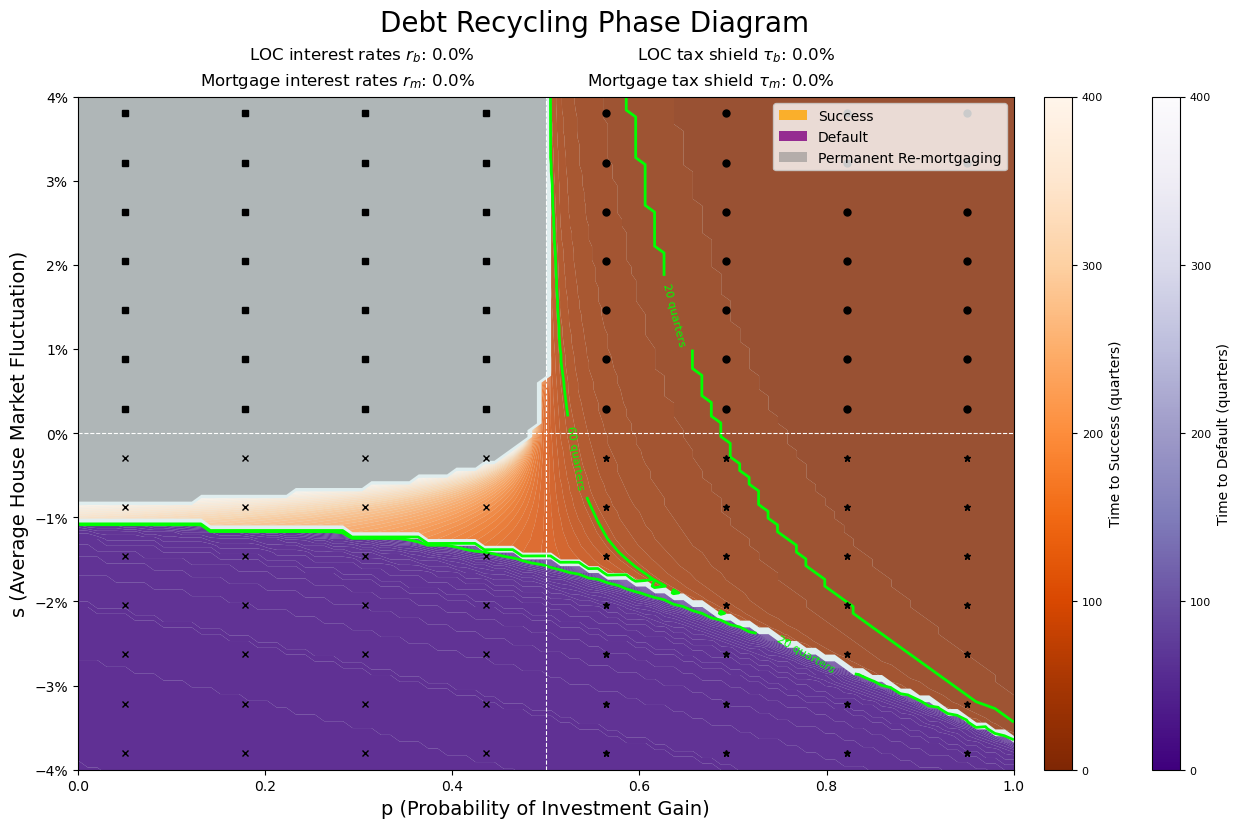

In [9]:
# Generating and Displaying Phase Diagram
print("Generating main phase diagram...")
plot_phase_diagram()

# Orange: Success, (strong or weak) on average the mortgage is fully repaid before equity depletes
# Purple: Fails, Equity hits zero first, the house becomes fully mortgaged 
# Gray: Permanent Remortgaging
# Default (purple) tends to happen much faster in bad conditions, so its range is smaller; failures typically occurs in a few years


### Scenarios Results 1: Methodology

In [102]:
scenarios_annual = {
    "Original": {"rb": 0.0, "rm": 0.0, "tb": 0.0, "tm": 0.0},
    "r_2_t_0": {"rb": 0.02, "rm": 0.02, "tb": 0.0, "tm": 0.0},
    "r_2_t_35": {"rb": 0.02, "rm": 0.02, "tb": 0.35, "tm": 0.35},
    "r_4_t_0": {"rb": 0.04, "rm": 0.04, "tb": 0.0, "tm": 0.0},
    "r_4_t_35": {"rb": 0.04, "rm": 0.04, "tb": 0.35, "tm": 0.35},
    "r_6_t_0": {"rb": 0.06, "rm": 0.06, "tb": 0.0, "tm": 0.0},
    "r_6_t_35": {"rb": 0.06, "rm": 0.06, "tb": 0.35, "tm": 0.35},
}

#  quarterly conversion only to interest rates (rb, rm)
scenarios = {
    name: {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in params.items()}
    for name, params in scenarios_annual.items()
}

# ranges for all scenarios
custom_ranges = {
    "P_RANGE": np.linspace(0.0, 1.0, 500),
    "S_RANGE": np.linspace(-0.04, 0.04, 500),
}

output_folder = "/Users/carlo/Documents/UCL/_Master_Thesis/Code/Images/PD_1_subplot"
os.makedirs(output_folder, exist_ok=True)

for name, params in scenarios.items():
    print(f"Running scenario: {name}")
    plot_phase_diagram(**params, **custom_ranges)
    plt.savefig(
        os.path.join(output_folder, f"PD_{name.replace(' ', '_')}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

Running scenario: Original
Generating phase diagram...
Running scenario: r_2_t_0
Generating phase diagram...
Running scenario: r_2_t_35
Generating phase diagram...
Running scenario: r_4_t_0
Generating phase diagram...
Running scenario: r_4_t_35
Generating phase diagram...
Running scenario: r_6_t_0
Generating phase diagram...
Running scenario: r_6_t_35
Generating phase diagram...


### Scenarios Results 2: Countries

In [106]:

scenarios_annual = {
    "Australia Self-Owned": {"rb": 0.0835, "rm": 0.0607, "tb": m_a, "tm": 0.0},
    "Australia rented": {"rb": 0.0835, "rm": 0.0628, "tb": m_a, "tm": m_a},
    "Germany Self-Owned": {"rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": 0.0},
    "Germany Rented": {"rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": m_g},
    "Switzerland both": {"rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s},
}

#  quarterly conversion only to interest rates (rb, rm)
scenarios = {
    name: {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in params.items()}
    for name, params in scenarios_annual.items()
}

# ranges for all scenarios
custom_ranges = {
    "P_RANGE": np.linspace(0.0, 1.0, 500),
    "S_RANGE": np.linspace(-0.04, 0.04, 500),
}

output_folder = "/Users/carlo/Documents/UCL/_Master_Thesis/Code/Images/PD_1_subplot"
os.makedirs(output_folder, exist_ok=True)

for name, params in scenarios.items():
    print(f"Running scenario: {name}")
    plot_phase_diagram(**params, **custom_ranges)
    plt.savefig(
        os.path.join(output_folder, f"PD_{name.replace(' ', '_')}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

Running scenario: Australia Self-Owned
Generating phase diagram...
Running scenario: Australia rented
Generating phase diagram...
Running scenario: Germany Self-Owned
Generating phase diagram...
Running scenario: Germany Rented
Generating phase diagram...
Running scenario: Switzerland both
Generating phase diagram...


## Plot 2 Phase Diagrams + Scenarios (methodology)

In [148]:
# Cell: Visualization — two subplots with shared legend/colorbars/titles
def plot_two_phase_diagrams(
    left_params, right_params,
    l=0.5, u=0.5,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    P_RANGE=P_RANGE, S_RANGE=S_RANGE,
    figsize=(14.5, 8.0)
):
    #  compute both panels using existing generator 
    P_L, S_L, out_L, t_L, _ = generate_phase_diagram(
        l, u, E0, M0, pi_star, q,
        rb=left_params['rb'], rm=left_params['rm'], tb=left_params['tb'], tm=left_params['tm'],
        P_RANGE=P_RANGE, S_RANGE=S_RANGE
    )
    P_R, S_R, out_R, t_R, _ = generate_phase_diagram(
        l, u, E0, M0, pi_star, q,
        rb=right_params['rb'], rm=right_params['rm'], tb=right_params['tb'], tm=right_params['tm'],
        P_RANGE=P_RANGE, S_RANGE=S_RANGE
    )

    #  figure and axes 
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=True,
                            gridspec_kw={'width_ratios':[1,1], 'wspace':0.06})
    plt.subplots_adjust(top=0.84, bottom=0.16, left=0.08, right=0.86, wspace=0.045)

    def _panel(ax, P, S, outcomes, times):
        ax.set_facecolor((0.878, 0.933, 0.937))
        # masks using the same approach as your original plotting cell
        success_mask  = np.array([[outcomes[i, j] == 'success'   for j in range(outcomes.shape[1])] for i in range(outcomes.shape[0])])
        default_mask  = np.array([[outcomes[i, j] == 'default'   for j in range(outcomes.shape[1])] for i in range(outcomes.shape[0])])
        permanent_mask= np.array([[outcomes[i, j] == 'permanent' for j in range(outcomes.shape[1])] for i in range(outcomes.shape[0])])

        # filled regions
        im_succ = ax.contourf(P, S, np.where(success_mask,  times, np.nan), 50, cmap='Oranges_r', norm=Normalize(0,400), alpha=0.8)
        im_def  = ax.contourf(P, S, np.where(default_mask,  times, np.nan), 50, cmap='Purples_r', norm=Normalize(0,400), alpha=0.8)
        im_perm = ax.contourf(P, S, permanent_mask.astype(float), levels=[0.5,1.5], colors=['gray'], alpha=0.5)

        # kill white seams
        for im in (im_perm, im_def, im_succ):
            for coll in im.collections:
                coll.set_edgecolor('face'); coll.set_linewidth(0); coll.set_antialiased(True); coll.set_rasterized(True)

        # contour lines (20, 60 quarters)
        cs = ax.contour(P, S, times, levels=[20,60], colors='lime', linewidths=2)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%d quarters')

        # reference lines
        ax.axvline(0.5, color='white', linestyle='--', linewidth=0.8)
        ax.axhline(0.0, color='white', linestyle='--', linewidth=0.8)

        # markers like in your original cell
        p_vals = np.linspace(0.05, 0.95, 8)
        s_vals = np.linspace(-0.038, 0.038, 14)
        Pm, Sm = np.meshgrid(p_vals, s_vals)
        Pf, Sf = Pm.ravel(), Sm.ravel()
        m = (Sf > 0) & (Pf < 0.5);  ax.plot(Pf[m], Sf[m], 's', color='black', markersize=5)
        m = (Sf > 0) & (Pf >= 0.5); ax.plot(Pf[m], Sf[m], 'o', color='black', markersize=5)
        m = (Sf <= 0) & (Pf < 0.5); ax.plot(Pf[m], Sf[m], 'x', color='black', markersize=5)
        m = (Sf <= 0) & (Pf >= 0.5);ax.plot(Pf[m], Sf[m], '*', color='black', markersize=5)

    # both panels
    _panel(axs[0], P_L, S_L, out_L, t_L)
    _panel(axs[1], P_R, S_R, out_R, t_R)

    # axes formatting (shared y labels/ticks only on the left; x ticks on both)
    for ax in axs:
        ax.set_xlim(0,1); ax.set_xticks(np.linspace(0,1,11))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        ax.set_yticks(np.linspace(-0.04, 0.04, 9))
        ax.tick_params(axis='both', labelsize=9)
    axs[0].set_ylabel('s (Average House Market Fluctuation)', fontsize=12)
    axs[1].tick_params(labelleft=False)
    fig.supxlabel('p (Probability of Investment Gain)', fontsize=12, y=0.088)

    #  titles and subtitles 
    fig.suptitle('Debt Recycling Phase Diagram', fontsize=20, y=0.975)
    pct      = lambda x: f"{x*100:.1f}%"                    # plain percent for τ_b, τ_m
    pct_ann  = lambda x: f"{((1.0 + x)**4 - 1.0)*100:.1f}%" # annualize quarterly for r_b, r_m 
    Ltxt = rf"LOC interest rates $r_b$: {pct_ann(left_params['rb'])}"  + "\n" + \
           rf"Mortgage interest rates $r_m$: {pct_ann(left_params['rm'])}" + "\n" + \
           rf"Tax Shield $t_m = t_b$: {pct(left_params['tm'])}"
    Rtxt = rf"LOC interest rates $r_b$: {pct_ann(right_params['rb'])}" + "\n" + \
           rf"Mortgage interest rates $r_m$: {pct_ann(right_params['rm'])}" + "\n" + \
           rf"Tax Shield $t_m = t_b$: {pct(right_params['tm'])}"
    boxL, boxR = axs[0].get_position(), axs[1].get_position()
    fig.text(boxL.x0 + boxL.width/2, 0.93, Ltxt, ha='center', va='top', fontsize=11, linespacing=1.35)
    fig.text(boxR.x0 + boxR.width/2, 0.93, Rtxt, ha='center', va='top', fontsize=11, linespacing=1.35)

    #  single legend for both panels 
    legend_handles = [
        plt.Rectangle((0,0),1,1,facecolor='orange',alpha=0.8,label='Success'),
        plt.Rectangle((0,0),1,1,facecolor='purple',alpha=0.8,label='Default'),
        plt.Rectangle((0,0),1,1,facecolor='gray',alpha=0.5,label='Permanent Re-mortgaging'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.985,0.962),
               frameon=True, fontsize=10)

    #  one pair of colorbars on the far right (shared scales 0–400) 
    norm = Normalize(0, 400)
    sm_succ = ScalarMappable(norm=norm, cmap='Oranges_r'); sm_succ.set_array([])
    sm_def  = ScalarMappable(norm=norm, cmap='Purples_r'); sm_def.set_array([])

    # narrow panels slightly to create extra right-side space for the bars
    for ax in axs:
        b = ax.get_position()
        ax.set_position([b.x0 - 0.005, b.y0, b.width - 0.01, b.height])
    boxR = axs[1].get_position()

    cax_h = boxR.height * 0.74
    cax_y = boxR.y0 + (boxR.height - cax_h) * 0.53
    cax_w = 0.015

    cax_succ = fig.add_axes([boxR.x1 + 0.020, cax_y, cax_w, cax_h])
    cax_def  = fig.add_axes([boxR.x1 + 0.095, cax_y, cax_w, cax_h])

    cb1 = plt.colorbar(sm_succ, cax=cax_succ)
    cb1.set_label('Time to Success (quarters)', fontsize=9)
    cb1.set_ticks([0,100,200,300,400]); cb1.ax.tick_params(labelsize=8)

    cb2 = plt.colorbar(sm_def,  cax=cax_def)
    cb2.set_label('Time to Default (quarters)', fontsize=9)
    cb2.set_ticks([0,100,200,300,400]); cb2.ax.tick_params(labelsize=8)

    return fig, axs


In [151]:
# Cell: specify the two scenarios 
left_scn_a  = {"rb": 0.02, "rm": 0.02, "tb": 0.0, "tm": 0.0}  # r_2_t_0
right_scn_a = {"rb": 0.06, "rm": 0.06, "tb": 0.0, "tm": 0.0}  # r_6_t_0

left_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in left_scn_a.items()}
right_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in right_scn_a.items()}

P_RANGE = np.linspace(0.0, 1.0, 500)      
S_RANGE = np.linspace(-0.04, 0.04, 500) 


fig, axs = plot_two_phase_diagrams(
    left_params=left_scn, right_params=right_scn,
    P_RANGE=P_RANGE, S_RANGE=S_RANGE, figsize=(14.5, 8.0)
)

output_folder = "/Users/carlo/Documents/UCL/_Master_Thesis/Code/Images/PD_2_subplot_meth"
os.makedirs(output_folder, exist_ok=True)
plt.savefig(os.path.join(output_folder, "PD_r2_vs_r6_two_panel.png"), dpi=300, bbox_inches="tight")
plt.close(fig)


Generating phase diagram...
Generating phase diagram...


In [152]:
# Cell: specify the two scenarios 
left_scn_a  = {"rb": 0.02, "rm": 0.02, "tb": 0.35, "tm": 0.35}  
right_scn_a = {"rb": 0.06, "rm": 0.06, "tb": 0.35, "tm": 0.35}  

left_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in left_scn_a.items()}
right_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in right_scn_a.items()}

P_RANGE = np.linspace(0.0, 1.0, 500)      
S_RANGE = np.linspace(-0.04, 0.04, 500) 

fig, axs = plot_two_phase_diagrams(
    left_params=left_scn, right_params=right_scn,
    P_RANGE=P_RANGE, S_RANGE=S_RANGE, figsize=(14.5, 8.0)
)

output_folder = "/Users/carlo/Documents/UCL/_Master_Thesis/Code/Images/PD_2_subplot_meth"
os.makedirs(output_folder, exist_ok=True)
plt.savefig(os.path.join(output_folder, "PD_r2t03_vs_r6t35_two_panel.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

Generating phase diagram...
Generating phase diagram...


## Plot 3 Phase Diagrams + Scenarios (country)

In [267]:
# Cell: Visualization — three subplots with shared legend/colorbars/titles
def plot_three_phase_diagrams(
    left_params, mid_params, right_params,
    l=0.5, u=0.5,
    E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
    pi_star=DEFAULT_PARAMS['pi_star'], q=DEFAULT_PARAMS['q'],
    P_RANGE=P_RANGE, S_RANGE_L=S_RANGE, S_RANGE_M=S_RANGE, S_RANGE_R=S_RANGE,
    figsize=(20.0, 8.0)
):
    #  compute all panels using existing generator 
    P_L, S_L, out_L, t_L, _ = generate_phase_diagram(
        l, u, E0, M0, pi_star, q,
        rb=left_params['rb'], rm=left_params['rm'], tb=left_params['tb'], tm=left_params['tm'],
        P_RANGE=P_RANGE, S_RANGE=S_RANGE_L
    )
    P_M, S_M, out_M, t_M, _ = generate_phase_diagram(
        l, u, E0, M0, pi_star, q,
        rb=mid_params['rb'], rm=mid_params['rm'], tb=mid_params['tb'], tm=mid_params['tm'],
        P_RANGE=P_RANGE, S_RANGE=S_RANGE_M
    )
    P_R, S_R, out_R, t_R, _ = generate_phase_diagram(
        l, u, E0, M0, pi_star, q,
        rb=right_params['rb'], rm=right_params['rm'], tb=right_params['tb'], tm=right_params['tm'],
        P_RANGE=P_RANGE, S_RANGE=S_RANGE_R
    )

    #  figure and axes 
    fig, axs = plt.subplots(1, 3, figsize=figsize, sharey=False,
                            gridspec_kw={'width_ratios':[1,1,1], 'wspace':0.06})
    plt.subplots_adjust(top=0.8, bottom=0.16, left=0.06, right=0.86, wspace=0.04)

    def _panel(ax, P, S, outcomes, times):
        ax.set_facecolor((0.878, 0.933, 0.937))
        success_mask   = np.array([[outcomes[i, j] == 'success'   for j in range(outcomes.shape[1])] for i in range(outcomes.shape[0])])
        default_mask   = np.array([[outcomes[i, j] == 'default'   for j in range(outcomes.shape[1])] for i in range(outcomes.shape[0])])
        permanent_mask = np.array([[outcomes[i, j] == 'permanent' for j in range(outcomes.shape[1])] for i in range(outcomes.shape[0])])

        im_succ = ax.contourf(P, S, np.where(success_mask,  times, np.nan), 50, cmap='Oranges_r', norm=Normalize(0,400), alpha=0.8)
        im_def  = ax.contourf(P, S, np.where(default_mask,  times, np.nan), 50, cmap='Purples_r', norm=Normalize(0,400), alpha=0.8)
        im_perm = ax.contourf(P, S, permanent_mask.astype(float), levels=[0.5,1.5], colors=['gray'], alpha=0.5)

        for im in (im_perm, im_def, im_succ):
            for coll in im.collections:
                coll.set_edgecolor('face'); coll.set_linewidth(0); coll.set_antialiased(True); coll.set_rasterized(True)

        cs = ax.contour(P, S, times, levels=[20,60], colors='lime', linewidths=2)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%d quarters')

        ax.axvline(0.5, color='white', linestyle='--', linewidth=0.8)
        ax.axhline(0.0, color='white', linestyle='--', linewidth=0.8)

        #  evenly cover each panel's domain with a small margin 
        p_min, p_max = float(P.min()), float(P.max())
        s_min, s_max = float(S.min()), float(S.max())

        n_p, n_s = 8, 14        # keep or adjust
        m_p, m_s = 0.05, 0.05   # 2% margin of the data range on each side; tune 0.01–0.05
        p_rng = p_max - p_min
        s_rng = s_max - s_min
        p_lo = p_min + m_p * p_rng
        p_hi = p_max - m_p * p_rng
        s_lo = s_min + m_s * s_rng
        s_hi = s_max - m_s * s_rng
        # include endpoints within the trimmed box → evenly spread, no axis hits, no big outer gaps
        p_vals = np.linspace(p_lo, p_hi, n_p, endpoint=True)
        s_vals = np.linspace(s_lo, s_hi, n_s, endpoint=True)
        Pm, Sm = np.meshgrid(p_vals, s_vals)
        Pf, Sf = Pm.ravel(), Sm.ravel()
        # quadrant markers (unchanged)
        m = (Sf > 0) & (Pf < 0.5);   ax.plot(Pf[m], Sf[m], 's', color='black', markersize=5, clip_on=True)
        m = (Sf > 0) & (Pf >= 0.5);  ax.plot(Pf[m], Sf[m], 'o', color='black', markersize=5, clip_on=True)
        m = (Sf <= 0) & (Pf < 0.5);  ax.plot(Pf[m], Sf[m], 'x', color='black', markersize=5, clip_on=True)
        m = (Sf <= 0) & (Pf >= 0.5); ax.plot(Pf[m], Sf[m], '*', color='black', markersize=5, clip_on=True)


        # Default example (red X at p=0.4, s=-1.5%)
        ax.plot(0.40, -0.015, 'x', color='red', markersize=10, markeredgewidth=2, label="Default Scenario")

        # Success example (green circle at p=0.6, s=+1.5%)
        ax.plot(0.60,  0.015,'x', color='#32CD32', markersize=10, markeredgewidth=2, label="Success Scenario")

    #  three panels
    _panel(axs[0], P_L, S_L, out_L, t_L)
    _panel(axs[1], P_M, S_M, out_M, t_M)
    _panel(axs[2], P_R, S_R, out_R, t_R)

    # axes formatting (shared y on the left only; x ticks on all)
    for ax, S in zip(axs, [S_L, S_M, S_R]):
        ax.set_xlim(0,1); ax.set_xticks(np.linspace(0,1,5))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        ax.set_ylim(S.min(), S.max())
        ax.set_yticks(np.linspace(S.min(), S.max(), 5))
        ax.tick_params(axis='both', labelsize=9)
    axs[0].set_ylabel('s (Average House Market Fluctuation)', fontsize=12)
    axs[1].tick_params(labelleft=True)
    axs[2].tick_params(labelleft=True)
    #fig.supxlabel('p (Probability of Investment Gain)', fontsize=12, y=0.088)
    fig.text(0.44, 0.1, 'p (Probability of Investment Gain)',
         ha='center', va='center', fontsize=12)

    #  titles and subtitles 
    fig.suptitle('Debt Recycling Phase Diagram', fontsize=20, y=0.992, x=0.45)
    # Country headers above each column
    boxL, boxM, boxR = axs[0].get_position(), axs[1].get_position(), axs[2].get_position()
    fig.text(boxL.x0 + boxL.width/2, 0.93, "Australia",   ha='center', va='bottom', fontsize=12, fontweight='bold')
    fig.text(boxM.x0 + boxM.width/2, 0.93, "Germany",     ha='center', va='bottom', fontsize=12, fontweight='bold')
    fig.text(boxR.x0 + boxR.width/2, 0.93, "Switzerland", ha='center', va='bottom', fontsize=12, fontweight='bold')

    pct      = lambda x: f"{x*100:.1f}%"                    # plain percent for τ_b, τ_m
    pct_ann  = lambda x: f"{((1.0 + x)**4 - 1.0)*100:.1f}%" # annualize quarterly for r_b, r_m 

    Ltxt = (
        rf"LOC interest rates $r_b$: {pct_ann(left_params['rb'])}"    + "\n" +
        rf"Mortgage interest rates $r_m$: {pct_ann(left_params['rm'])}" + "\n" +
        rf"Mortgage tax shield $\tau_m$: {pct(left_params['tm'])}" + "\n" +
        rf"LOC tax shield $\tau_b$: {pct(left_params['tb'])}"
    )
    Mtxt = (
        rf"LOC interest rates $r_b$: {pct_ann(mid_params['rb'])}"     + "\n" +
        rf"Mortgage interest rates $r_m$: {pct_ann(mid_params['rm'])}" + "\n" +
        rf"Mortgage tax shield $\tau_m$: {pct(mid_params['tm'])}"  + "\n" +
        rf"LOC tax shield $\tau_b$: {pct(mid_params['tb'])}"
    )
    Rtxt = (
        rf"LOC interest rates $r_b$: {pct_ann(right_params['rb'])}"   + "\n" +
        rf"Mortgage interest rates $r_m$: {pct_ann(right_params['rm'])}" + "\n" +
        rf"Mortgage tax shield $\tau_m$: {pct(right_params['tm'])}"  + "\n" +
        rf"LOC tax shield $\tau_b$: {pct(right_params['tb'])}"
    )

    boxL, boxM, boxR = axs[0].get_position(), axs[1].get_position(), axs[2].get_position()
    fig.text(boxL.x0 + boxL.width/2, 0.915, Ltxt, ha='center', va='top', fontsize=11, linespacing=1.35)
    fig.text(boxM.x0 + boxM.width/2, 0.915, Mtxt, ha='center', va='top', fontsize=11, linespacing=1.35)
    fig.text(boxR.x0 + boxR.width/2, 0.915, Rtxt, ha='center', va='top', fontsize=11, linespacing=1.35)

    #  single legend for all panels 
    legend_handles = [
        plt.Rectangle((0,0),1,1,facecolor='orange',alpha=0.8,label='Success'),
        plt.Rectangle((0,0),1,1,facecolor='purple',alpha=0.8,label='Default'),
        plt.Rectangle((0,0),1,1,facecolor='gray',alpha=0.5,label='Permanent Re-mortgaging'),
        plt.Line2D([0],[0], marker='x', color='red', markersize=8, linestyle='None', label='Default Scenario'),
        plt.Line2D([0],[0], marker='x', color='#32CD32', markersize=8, linestyle='None', label='Success Scenario'),
    ]
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.985,0.962), frameon=True, fontsize=10)

    #  one pair of colorbars on the far right (shared scales 0–400) 
    norm = Normalize(0, 400)
    sm_succ = ScalarMappable(norm=norm, cmap='Oranges_r'); sm_succ.set_array([])
    sm_def  = ScalarMappable(norm=norm, cmap='Purples_r'); sm_def.set_array([])

    # narrow panels slightly to create extra right-side space for the bars
    for ax in axs:
        b = ax.get_position()
        ax.set_position([b.x0 - 0.004, b.y0, b.width - 0.012, b.height])
    boxR = axs[2].get_position()

    cax_h = boxR.height * 0.74
    cax_y = boxR.y0 + (boxR.height - cax_h) * 0.53
    cax_w = 0.015

    cax_succ = fig.add_axes([boxR.x1 + 0.020, cax_y, cax_w, cax_h])
    cax_def  = fig.add_axes([boxR.x1 + 0.070, cax_y, cax_w, cax_h])

    cb1 = plt.colorbar(sm_succ, cax=cax_succ)
    cb1.set_label('Time to Success (quarters)', fontsize=9)
    cb1.set_ticks([0,100,200,300,400]); cb1.ax.tick_params(labelsize=8)

    cb2 = plt.colorbar(sm_def,  cax=cax_def)
    cb2.set_label('Time to Default (quarters)', fontsize=9)
    cb2.set_ticks([0,100,200,300,400]); cb2.ax.tick_params(labelsize=8)

    return fig, axs


In [269]:
# Cell: specify three scenarios 
# grid
P_RANGE = np.linspace(0.0, 1.0, 500)
S_RANGE_L = np.linspace(-0.04, 0.04, 500)  # Australia
S_RANGE_M = np.linspace(-0.06, 0.06, 500)  # Germany
S_RANGE_R = np.linspace(-0.02, 0.02, 500)  # Switzerland


left_scn_a  = {"rb": 0.0835, "rm": 0.0607, "tb": m_a, "tm": 0.0}  # Australia
mid_scn_a   = {"rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": 0.0}  # Germany
right_scn_a = {"rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s}  # Switzerland

left_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in left_scn_a.items()}
mid_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in mid_scn_a.items()}
right_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in right_scn_a.items()}

fig, axs = plot_three_phase_diagrams(
    left_params=left_scn, mid_params=mid_scn, right_params=right_scn,
    P_RANGE=P_RANGE, S_RANGE_L=S_RANGE_L, S_RANGE_M=S_RANGE_M, S_RANGE_R=S_RANGE_R, figsize=(20.0, 8.0)
)

output_folder = "/Users/carlo/Documents/UCL/_Master_Thesis/Code/Images/PD_3_subplot_country"
os.makedirs(output_folder, exist_ok=True)
plt.savefig(os.path.join(output_folder, "Owned_per_Country.png"), dpi=300, bbox_inches="tight")
plt.close(fig)


Generating phase diagram...
Generating phase diagram...
Generating phase diagram...


In [270]:
# Cell: specify three scenarios
#  grid
P_RANGE = np.linspace(0.0, 1.0, 500)
S_RANGE_L = np.linspace(-0.04, 0.04, 500)  # Australia
S_RANGE_M = np.linspace(-0.06, 0.06, 500)  # Germany
S_RANGE_R = np.linspace(-0.02, 0.02, 500)  # Switzerland

left_scn_a  = {"rb": 0.0835, "rm": 0.0628, "tb": m_a, "tm": m_a}  # Australia
mid_scn_a   = {"rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": m_g}  # Germany
right_scn_a = {"rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s}  # Switzerland

left_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in left_scn_a.items()}
mid_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in mid_scn_a.items()}
right_scn = {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in right_scn_a.items()}

fig, axs = plot_three_phase_diagrams(
    left_params=left_scn, mid_params=mid_scn, right_params=right_scn,
    P_RANGE=P_RANGE, S_RANGE_L=S_RANGE_L, S_RANGE_M=S_RANGE_M, S_RANGE_R=S_RANGE_R, figsize=(20.0, 8.0)
)

output_folder = "/Users/carlo/Documents/UCL/_Master_Thesis/Code/Images/PD_3_subplot_country"
os.makedirs(output_folder, exist_ok=True)
plt.savefig(os.path.join(output_folder, "Rented_per_Country.png"), dpi=300, bbox_inches="tight")
plt.close(fig)


Generating phase diagram...
Generating phase diagram...
Generating phase diagram...


# Simulations

## Stochastic Monte Carlo Simulations

It simulates many sample paths, aggregates empirical means/stds, and compares them to the theoretical averages. 
It’s designed to show the spread around the analytic expectation.

In [48]:
# Cell Block 14
def simulate_single_trajectory(l, u, p, s,
                               E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
                               pi_star=DEFAULT_PARAMS['pi_star'],
                               max_time=50, phi=0.01, seed=None,
                               rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
                               tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']):
    """
    Simulate a single trajectory of the debt recycling process (Model 5-ready)

    Stochastic base equations (paper, eqs. (4) & (5)), extended for Model 5:
        E_t = E_{t-1} + π_t + I_{t-1} + H_{t-1} * r_t
              − (1 − τ_b) * r_b * U_{t-1}      + τ_m * r_m * M_{t-1}
        M_t = M_{t-1} − π_t − I_{t-1} + r_m * M_{t-1}

    where:
        U_{t-1} = l * E_{t-1}                      (eq. 2)
        I_{t-1} = σ_t * u * U_{t-1}                (eq. 3),  σ_t∈{+1,−1} with P(σ_t=+1)=p (eq. 11/12)
        r_t  ~ Normal(mean=s, std=φ)               (eq. 13)
        π_t  = π* with prob 1−q, else 0            (eq. 14/15)
        H_{t-1} = E_{t-1} + M_{t-1}                (eq. 1)
        r_b ≥ 0 borrowing cost on U; τ_b tax shield on borrowing interest
        r_m ≥ 0 mortgage interest;   τ_m tax shield on mortgage interest

    Notes:
    - Borrowing cost tax shield τ_b reduces the equity outflow due to r_b * U.
    - Mortgage interest r_m accrues on M, while τ_m * r_m * M is a cash tax shield increasing equity.
    """
    if seed is not None:
        np.random.seed(seed)

    # arrays to store  trajectory
    time_steps = np.arange(0, max_time + 1)
    E_trajectory = np.zeros(len(time_steps))
    M_trajectory = np.zeros(len(time_steps))

    # initial conditions
    E_trajectory[0] = E0
    M_trajectory[0] = M0

    for t in range(1, len(time_steps)):

        # Investment outcome: +1 with probability p, -1 with probability (1-p)  (eq. 11/12)
        sigma_t = 1 if np.random.random() < p else -1

        # House market fluctuation: r_t ~ N(s, φ²)  (eq. 13)
        r_t = np.random.normal(s, phi)

        # Payment: π* with probability (1−q), else 0  (eq. 14/15)
        pi_t = pi_star

        #  Previous state 
        E_prev = E_trajectory[t - 1]
        M_prev = M_trajectory[t - 1]
        H_prev = E_prev + M_prev  # (eq. 1)

        #  Investment and borrowing 
        U_t = l * E_prev                    # (eq. 2)
        I_t = sigma_t * u * U_t             # (eq. 3)

        # Costs/interest and tax shields (Model 5)
        mort_interest = rm * M_prev                   # mortgage interest accrual
        mort_tax_shield = tm * mort_interest          # τ_m * r_m * M_prev
        borrow_cost_net = (1.0 - tb) * rb * U_t       # (1−τ_b) * r_b * U_t

        #  Updates (Model 5) 
        # Equity receives payment, realized investment, house return;
        # pays net borrowing cost; receives mortgage interest tax shield
        E_trajectory[t] = (
            E_prev + pi_t + I_t + H_prev * r_t
            - borrow_cost_net + mort_tax_shield
        )

        # Mortgage is reduced by payment and investment proceeds, and grows by mortgage interest
        M_trajectory[t] = M_prev - pi_t - I_t + mort_interest

        # (Optional stopping at first boundary — keep commented to match paper's continuous lines)
        # if E_trajectory[t] <= 0 or M_trajectory[t] <= 0:
        #     E_trajectory = E_trajectory[:t+1]
        #     M_trajectory = M_trajectory[:t+1]
        #     time_steps = time_steps[:t+1]
        #     break

    return time_steps, E_trajectory, M_trajectory


In [49]:
# Cell Block 15
def run_multiple_simulations(l, u, p, s,
                             E0=DEFAULT_PARAMS['E0'], M0=DEFAULT_PARAMS['M0'],
                             pi_star=DEFAULT_PARAMS['pi_star'],
                             max_time=50, phi=0.01, n_simulations=1000,
                             rb=DEFAULT_PARAMS['rb'], rm=DEFAULT_PARAMS['rm'],
                             tb=DEFAULT_PARAMS['tb'], tm=DEFAULT_PARAMS['tm']):
    """
    Run multiple Monte Carlo simulations of the debt recycling process (Model 5-ready)

    Returns:
    - all_trajectories_E: list of equity trajectories
    - all_trajectories_M: list of mortgage trajectories
    - empirical_mean_E: empirical average equity over time
    - empirical_mean_M: empirical average mortgage over time
    - empirical_std_E: empirical standard deviation of equity
    - empirical_std_M: empirical standard deviation of mortgage
    - time_grid: numpy array of time indices corresponding to the empirical arrays
    """

    all_trajectories_E = []
    all_trajectories_M = []
    all_times = []

    print(f"Running {n_simulations} simulations... "
          f"(rb={rb}, rm={rm}, tb={tb}, tm={tm})")

    for i in range(n_simulations):
        if (i + 1) % 1000 == 0:
            print(f"Completed {i + 1} simulations")

        times, E_traj, M_traj = simulate_single_trajectory(
            l, u, p, s, E0, M0, pi_star,
            max_time=max_time, phi=phi, seed=i,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        all_trajectories_E.append(E_traj)
        all_trajectories_M.append(M_traj)
        all_times.append(times)

    # empirical statistics at each time point
    max_time_observed = max(len(traj) for traj in all_trajectories_E)
    time_grid = np.arange(max_time_observed)

    empirical_mean_E = []
    empirical_mean_M = []
    empirical_std_E = []
    empirical_std_M = []

    for t in time_grid:
        # Collect all values at time t (only from trajectories that haven't ended)
        values_E_at_t = [traj[t] for traj in all_trajectories_E if len(traj) > t]
        values_M_at_t = [traj[t] for traj in all_trajectories_M if len(traj) > t]

        if values_E_at_t:  # If we have data at this time point
            empirical_mean_E.append(np.mean(values_E_at_t))
            empirical_std_E.append(np.std(values_E_at_t))
            empirical_mean_M.append(np.mean(values_M_at_t))
            empirical_std_M.append(np.std(values_M_at_t))
        else:
            break

    return (all_trajectories_E, all_trajectories_M,
            np.array(empirical_mean_E), np.array(empirical_mean_M),
            np.array(empirical_std_E), np.array(empirical_std_M),
            time_grid[:len(empirical_mean_E)])


# Thesis Simulation Experiments

## Sucess Scenario

In [249]:
# Multi-scenario Monte Carlo setup 

# Base params (pulled from your DEFAULT_PARAMS)
BASE_L  = DEFAULT_PARAMS['l']
BASE_U  = DEFAULT_PARAMS['u']
BASE_P  = DEFAULT_PARAMS['p']
BASE_S  = DEFAULT_PARAMS['s']
BASE_E0 = DEFAULT_PARAMS['E0']
BASE_M0 = DEFAULT_PARAMS['M0']
BASE_PI = DEFAULT_PARAMS['pi_star']
BASE_Q  = DEFAULT_PARAMS['q']  

MAX_TIME     = 30           # quarters
PHI          = 0.01         # house-return shock std
N_SIM        = 1000         # Monte Carlo paths per scenario
N_DISPLAY    = 5            # number of individual paths to overlay
SHOW_HITTING = True         #  t* vertical lines (per panel) using classify_outcome

BASE_L  = 0.5
BASE_U  = 0.5
BASE_P  = 0.6
BASE_S  = 0.015
BASE_E0 = 30000
BASE_M0 = 300000
BASE_PI = 3000
BASE_Q  = 0.01

# Three scenarios – edit rb, rm, tb, tm here
SCENARIOS_annual = [
    {
        "label": "No rates / No tax shield",
        "rb": 0.00, "rm": 0.00, "tb": 0.0, "tm": 0.0,
        "color": "#4F7CAC"  
    },
    {
        "label": "4% rates / No tax shield",
        "rb": 0.04, "rm": 0.04, "tb": 0.0, "tm": 0.0,
        "color": "#C65F5F"
    },
    {
        "label": "4% rates / 35% tax margin",
        "rb": 0.04, "rm": 0.04, "tb": 0.35, "tm": 0.35,
        "color": "#6BA368"
    }
]

SCENARIOS = [
    {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in scn.items()}
    for scn in SCENARIOS_annual
]

Running 1000 simulations... (rb=0.0, rm=0.0, tb=0.0, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.009853406548968824, rm=0.009853406548968824, tb=0.0, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.009853406548968824, rm=0.009853406548968824, tb=0.35, tm=0.35)
Completed 1000 simulations


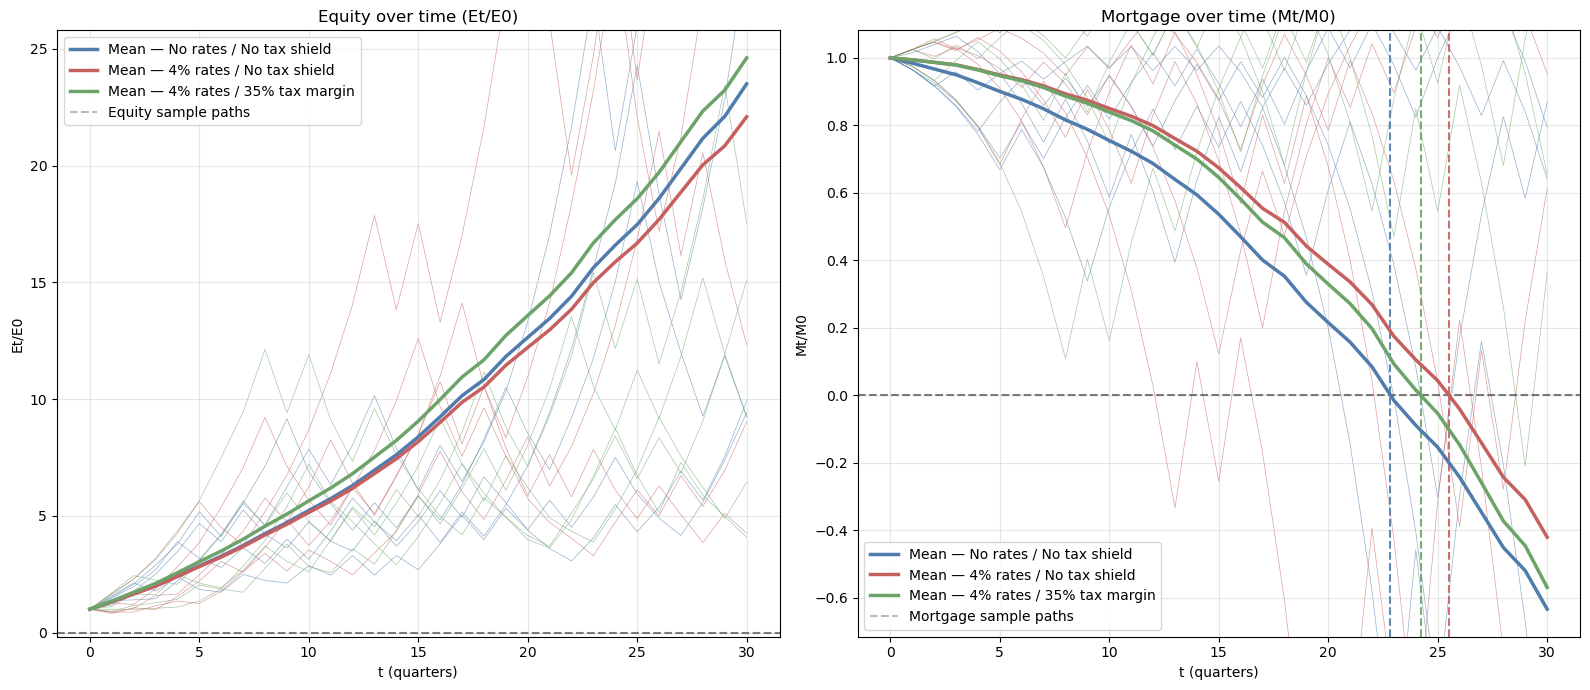

In [250]:


def plot_multi_scenario_trajectories():
    rng = np.random.default_rng(42)  # for reproducible path samples

    fig, (axE, axM) = plt.subplots(1, 2, figsize=(16, 7))
    axE.set_title('Equity over time (Et/E0)')
    axM.set_title('Mortgage over time (Mt/M0)')
    axE.set_xlabel('t (quarters)')
    axM.set_xlabel('t (quarters)')
    axE.set_ylabel('Et/E0')
    axM.set_ylabel('Mt/M0')
    for ax in (axE, axM):
        ax.grid(True, alpha=0.3)

    def _first_zero_crossing(time, y):
        # returns fractional t where y crosses from >0 to <=0; None if no crossing
        for i in range(1, len(y)):
            y0, y1 = y[i-1], y[i]
            if y0 == 0:          # exactly on grid
                return float(time[i-1])
            if (y0 > 0) and (y1 <= 0):
                t0, t1 = time[i-1], time[i]
                denom = (y0 - y1)
                frac = 1.0 if denom == 0 else max(0.0, min(1.0, y0/denom))
                return float(t0 + frac * (t1 - t0))
        return None

    # Track global y-limits across scenarios for consistent scaling
    e_lowers, e_uppers = [], []
    m_lowers, m_uppers = [], []

    # Collect legend handles
    legend_handles_E = []
    legend_handles_M = []
    sample_legend_added_E = False
    sample_legend_added_M = False

    time_grid_global = None  # assume same length across scenarios

    for sc in SCENARIOS:
        rb, rm, tb, tm = sc["rb"], sc["rm"], sc["tb"], sc["tm"]
        color = sc["color"]
        label = sc["label"]


        #  Run simulations for this scenario 
        (all_E, all_M, emp_mean_E, emp_mean_M,
         emp_std_E, emp_std_M, time_grid) = run_multiple_simulations(
            BASE_L, BASE_U, BASE_P, BASE_S,
            BASE_E0, BASE_M0,
            BASE_PI,                # deterministic payment value used by your simulator
            MAX_TIME, PHI, N_SIM,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        if time_grid_global is None:
            time_grid_global = time_grid

        # Normalize stats
        mean_E = emp_mean_E / BASE_E0
        mean_M = emp_mean_M / BASE_M0


        #  Plot mean trajectories 
        le, = axE.plot(time_grid, mean_E, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        lm, = axM.plot(time_grid, mean_M, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        legend_handles_E.append(le)
        legend_handles_M.append(lm)

        #   N_DISPLAY random individual paths  
        # pick distinct indices
        n_avail = len(all_E)
        pick = rng.choice(n_avail, size=min(N_DISPLAY, n_avail), replace=False)
        for idx in pick:
            e_traj = np.asarray(all_E[idx]) / BASE_E0
            m_traj = np.asarray(all_M[idx]) / BASE_M0
            tt = np.arange(len(e_traj))
            # equity sample paths
            axE.plot(tt, e_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_E else None)
            # mortgage sample paths
            axM.plot(tt, m_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_M else None)

        if not sample_legend_added_E:
            sample_legend_added_E = True
        if not sample_legend_added_M:
            sample_legend_added_M = True

        #  first hitting time as vertical line per panel 
        if SHOW_HITTING:
            tE = _first_zero_crossing(time_grid, mean_E)
            if tE is not None and tE <= MAX_TIME:
                axE.axvline(tE, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

            tM = _first_zero_crossing(time_grid, mean_M)
            if tM is not None and tM <= MAX_TIME:
                axM.axvline(tM, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)


        # accumulate bounds for global y-lims
        e_lowers.append(np.nanmin(mean_E))
        e_uppers.append(np.nanmax(mean_E))
        m_lowers.append(np.nanmin(mean_M))
        m_uppers.append(np.nanmax(mean_M))

    # Consistent y-limits across scenarios
    def pad(lo, hi, frac=0.05):
        span = hi - lo
        return lo - frac*span, hi + frac*span

    e_lo, e_hi = pad(np.nanmin(e_lowers), np.nanmax(e_uppers))
    m_lo, m_hi = pad(np.nanmin(m_lowers), np.nanmax(m_uppers))
    axE.set_ylim(e_lo, e_hi)
    axM.set_ylim(m_lo, m_hi)

    # Zero lines
    axE.axhline(0.0, color='k', linestyle='--', alpha=0.5)
    axM.axhline(0.0, color='k', linestyle='--', alpha=0.5)

    # Legends
    sample_E = Line2D([0], [0], color='0.65', lw=1.5, alpha=0.8, linestyle='--', label='Equity sample paths')
    sample_M = Line2D([0], [0], color='0.65',   lw=1.5, alpha=0.8, linestyle='--', label='Mortgage sample paths')
    axE.legend(handles=legend_handles_E + [sample_E], loc='best')
    axM.legend(handles=legend_handles_M + [sample_M], loc='best')

    plt.tight_layout()
    plt.show()


plot_multi_scenario_trajectories()


## Default Scenario

In [251]:
#Multi-scenario Monte Carlo setup 

# Base params 
BASE_L  = DEFAULT_PARAMS['l']
BASE_U  = DEFAULT_PARAMS['u']
BASE_P  = DEFAULT_PARAMS['p']
BASE_S  = DEFAULT_PARAMS['s']
BASE_E0 = DEFAULT_PARAMS['E0']
BASE_M0 = DEFAULT_PARAMS['M0']
BASE_PI = DEFAULT_PARAMS['pi_star']
BASE_Q  = DEFAULT_PARAMS['q']  

MAX_TIME     = 30          # quarters
PHI          = 0.01         # house-return shock std
N_SIM        = 1000         # Monte Carlo paths per scenario
N_DISPLAY    = 5            # number of individual paths to overlay
SHOW_HITTING = True         #  t* vertical lines (per panel) using classify_outcome

BASE_L  = 0.5
BASE_U  = 0.5
BASE_P  = 0.4
BASE_S  = -0.015
BASE_E0 = 30000
BASE_M0 = 300000
BASE_PI = 3000
BASE_Q  = 0.01

# Three scenarios – edit rb, rm, tb, tm here
SCENARIOS_annual = [
    {
        "label": "No rates / No tax shield",
        "rb": 0.00, "rm": 0.00, "tb": 0.0, "tm": 0.0,
        "color": "#4F7CAC"  
    },
    {
        "label": "4% rates / No tax shield",
        "rb": 0.04, "rm": 0.04, "tb": 0.0, "tm": 0.0,
        "color": "#C65F5F"
    },
    {
        "label": "4% rates / 35% tax shield",
        "rb": 0.04, "rm": 0.04, "tb": 0.35, "tm": 0.35,
        "color": "#6BA368"
    }
]

SCENARIOS = [
    {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in scn.items()}
    for scn in SCENARIOS_annual
]

Running 1000 simulations... (rb=0.0, rm=0.0, tb=0.0, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.009853406548968824, rm=0.009853406548968824, tb=0.0, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.009853406548968824, rm=0.009853406548968824, tb=0.35, tm=0.35)
Completed 1000 simulations


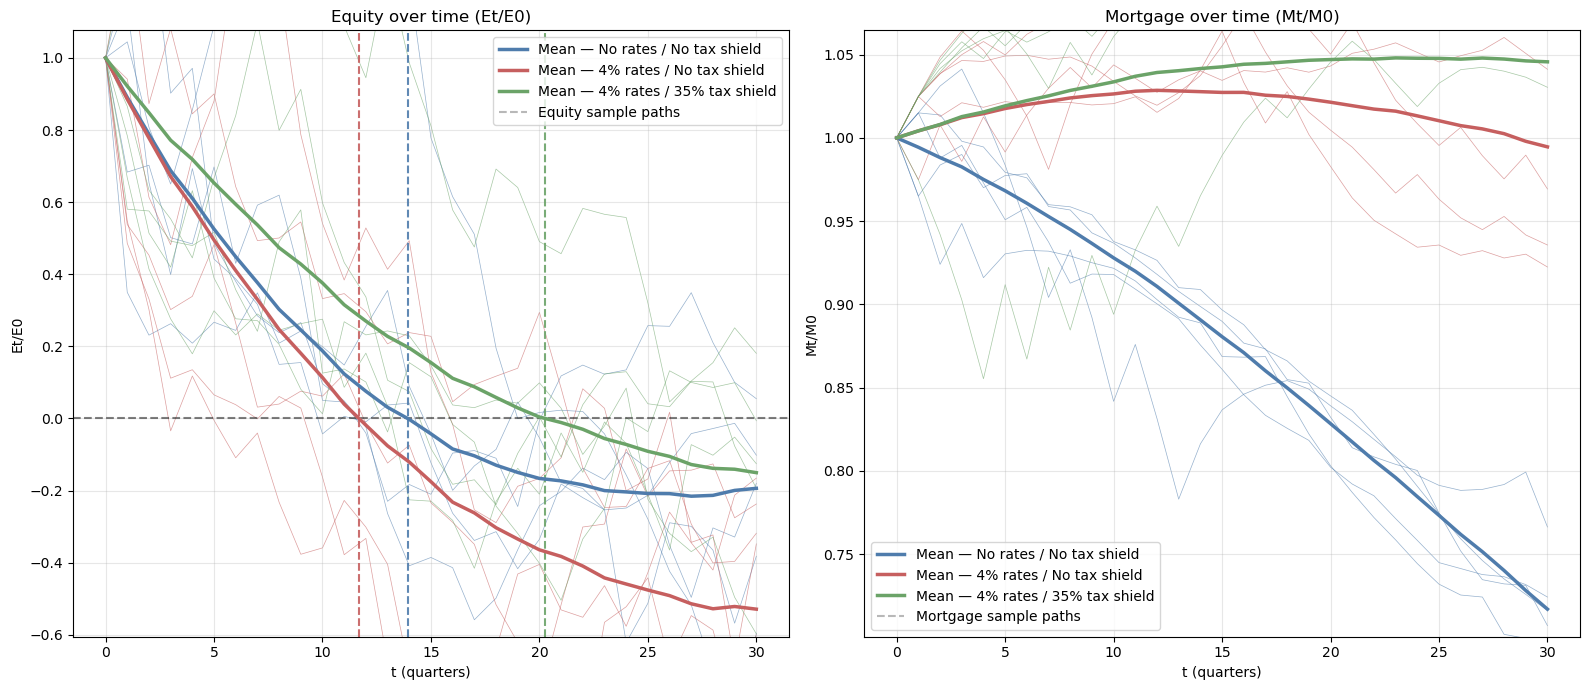

In [252]:


def plot_multi_scenario_trajectories():
    rng = np.random.default_rng(42)  # for reproducible path samples

    fig, (axE, axM) = plt.subplots(1, 2, figsize=(16, 7))
    axE.set_title('Equity over time (Et/E0)')
    axM.set_title('Mortgage over time (Mt/M0)')
    axE.set_xlabel('t (quarters)')
    axM.set_xlabel('t (quarters)')
    axE.set_ylabel('Et/E0')
    axM.set_ylabel('Mt/M0')
    for ax in (axE, axM):
        ax.grid(True, alpha=0.3)

    def _first_zero_crossing(time, y):
        # returns fractional t where y crosses from >0 to <=0; None if no crossing
        for i in range(1, len(y)):
            y0, y1 = y[i-1], y[i]
            if y0 == 0:          # exactly on grid
                return float(time[i-1])
            if (y0 > 0) and (y1 <= 0):
                t0, t1 = time[i-1], time[i]
                denom = (y0 - y1)
                frac = 1.0 if denom == 0 else max(0.0, min(1.0, y0/denom))
                return float(t0 + frac * (t1 - t0))
        return None

    # Track global y-limits across scenarios for consistent scaling
    e_lowers, e_uppers = [], []
    m_lowers, m_uppers = [], []

    # Collect legend handles
    legend_handles_E = []
    legend_handles_M = []
    sample_legend_added_E = False
    sample_legend_added_M = False

    time_grid_global = None  # assume same length across scenarios

    for sc in SCENARIOS:
        rb, rm, tb, tm = sc["rb"], sc["rm"], sc["tb"], sc["tm"]
        color = sc["color"]
        label = sc["label"]


        #  Run simulations for this scenario 
        (all_E, all_M, emp_mean_E, emp_mean_M,
         emp_std_E, emp_std_M, time_grid) = run_multiple_simulations(
            BASE_L, BASE_U, BASE_P, BASE_S,
            BASE_E0, BASE_M0,
            BASE_PI,                # deterministic payment value used by your simulator
            MAX_TIME, PHI, N_SIM,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        if time_grid_global is None:
            time_grid_global = time_grid

        # Normalize stats
        mean_E = emp_mean_E / BASE_E0
        mean_M = emp_mean_M / BASE_M0


        #  Plot mean trajectories (thick lines, scenario colors) 
        le, = axE.plot(time_grid, mean_E, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        lm, = axM.plot(time_grid, mean_M, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        legend_handles_E.append(le)
        legend_handles_M.append(lm)

        #   N_DISPLAY random individual paths (green/red) 
        # pick distinct indices
        n_avail = len(all_E)
        pick = rng.choice(n_avail, size=min(N_DISPLAY, n_avail), replace=False)
        for idx in pick:
            e_traj = np.asarray(all_E[idx]) / BASE_E0
            m_traj = np.asarray(all_M[idx]) / BASE_M0
            tt = np.arange(len(e_traj))
            # equity sample paths
            axE.plot(tt, e_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_E else None)
            # mortgage sample paths
            axM.plot(tt, m_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_M else None)

        if not sample_legend_added_E:
            sample_legend_added_E = True
        if not sample_legend_added_M:
            sample_legend_added_M = True

        #  first hitting time as vertical line per panel 
        if SHOW_HITTING:
            tE = _first_zero_crossing(time_grid, mean_E)
            if tE is not None and tE <= MAX_TIME:
                axE.axvline(tE, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

            tM = _first_zero_crossing(time_grid, mean_M)
            if tM is not None and tM <= MAX_TIME:
                axM.axvline(tM, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)


        # accumulate bounds for global y-lims
        e_lowers.append(np.nanmin(mean_E))
        e_uppers.append(np.nanmax(mean_E))
        m_lowers.append(np.nanmin(mean_M))
        m_uppers.append(np.nanmax(mean_M))

    # Consistent y-limits across scenarios
    def pad(lo, hi, frac=0.05):
        span = hi - lo
        return lo - frac*span, hi + frac*span

    e_lo, e_hi = pad(np.nanmin(e_lowers), np.nanmax(e_uppers))
    m_lo, m_hi = pad(np.nanmin(m_lowers), np.nanmax(m_uppers))
    axE.set_ylim(e_lo, e_hi)
    axM.set_ylim(m_lo, m_hi)

    # Zero lines
    axE.axhline(0.0, color='k', linestyle='--', alpha=0.5)
    axM.axhline(0.0, color='k', linestyle='--', alpha=0.5)

    # Legends
    # Add one legend entry explaining sample path colors
    sample_E = Line2D([0], [0], color='0.65', lw=1.5, alpha=0.8, linestyle='--', label='Equity sample paths')
    sample_M = Line2D([0], [0], color='0.65',   lw=1.5, alpha=0.8, linestyle='--', label='Mortgage sample paths')
    axE.legend(handles=legend_handles_E + [sample_E], loc='best')
    axM.legend(handles=legend_handles_M + [sample_M], loc='best')

    plt.tight_layout()
    plt.show()


plot_multi_scenario_trajectories()


## Country Success Scenario Self_owned

In [253]:
# Multi-scenario Monte Carlo setup 

# Base params 
BASE_L  = DEFAULT_PARAMS['l']
BASE_U  = DEFAULT_PARAMS['u']
BASE_P  = DEFAULT_PARAMS['p']
BASE_S  = DEFAULT_PARAMS['s']
BASE_E0 = DEFAULT_PARAMS['E0']
BASE_M0 = DEFAULT_PARAMS['M0']
BASE_PI = DEFAULT_PARAMS['pi_star']
BASE_Q  = DEFAULT_PARAMS['q']  


MAX_TIME     = 30          # quarters
PHI          = 0.01         # house-return shock std
N_SIM        = 1000         # Monte Carlo paths per scenario
N_DISPLAY    = 5            # number of individual paths to overlay
SHOW_HITTING = True         #  t* vertical lines (per panel) using classify_outcome

BASE_L  = 0.5
BASE_U  = 0.5
BASE_P  = 0.6 # 0.8
BASE_S  = 0.015 # 0.02
BASE_E0 = 30000
BASE_M0 = 300000
BASE_PI = 3000
BASE_Q  = 0.01

# Three scenarios – edit rb, rm, tb, tm here
SCENARIOS_annual = [
    {
        "label": "Australia",
        "rb": 0.0835, "rm": 0.0607, "tb": m_a, "tm": 0.0,
        "color": "#4F7CAC"  
    },
    {
        "label": "Germany",
        "rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": 0.0,
        "color": "#C65F5F"
    },
    {
        "label": "Switzerland",
        "rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s,
        "color": "#6BA368"
    }
]

SCENARIOS = [
    {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in scn.items()}
    for scn in SCENARIOS_annual
]

Running 1000 simulations... (rb=0.020251469359793717, rm=0.014841321609057934, tb=0.32, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.01309069972318655, rm=0.00910002891795858, tb=0.0, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.004025626196972665, rm=0.004025626196972665, tb=0.2011999999999999, tm=0.2011999999999999)
Completed 1000 simulations


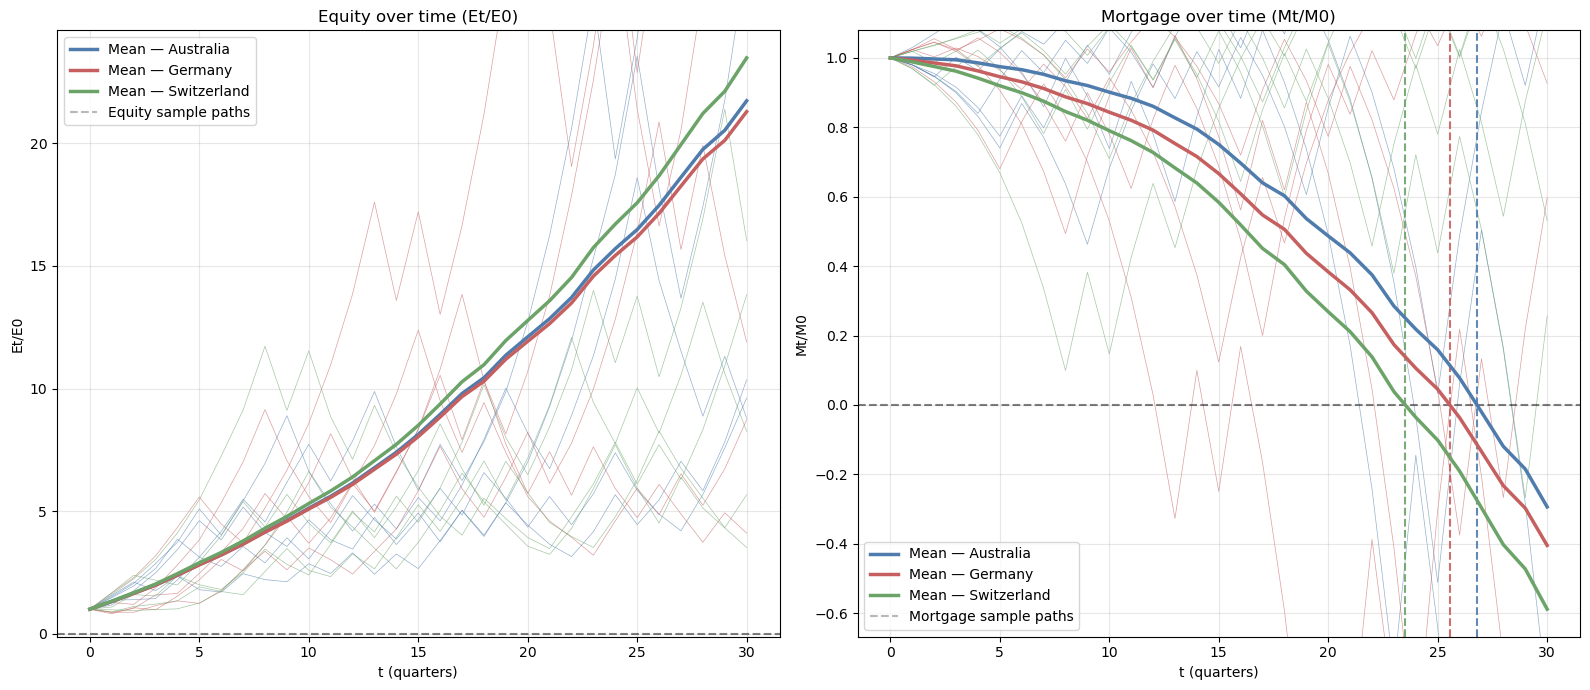

In [254]:


def plot_multi_scenario_trajectories():
    rng = np.random.default_rng(42)  # for reproducible path samples

    fig, (axE, axM) = plt.subplots(1, 2, figsize=(16, 7))
    axE.set_title('Equity over time (Et/E0)')
    axM.set_title('Mortgage over time (Mt/M0)')
    axE.set_xlabel('t (quarters)')
    axM.set_xlabel('t (quarters)')
    axE.set_ylabel('Et/E0')
    axM.set_ylabel('Mt/M0')
    for ax in (axE, axM):
        ax.grid(True, alpha=0.3)

    def _first_zero_crossing(time, y):
        # returns fractional t where y crosses from >0 to <=0; None if no crossing
        for i in range(1, len(y)):
            y0, y1 = y[i-1], y[i]
            if y0 == 0:          # exactly on grid
                return float(time[i-1])
            if (y0 > 0) and (y1 <= 0):
                t0, t1 = time[i-1], time[i]
                denom = (y0 - y1)
                frac = 1.0 if denom == 0 else max(0.0, min(1.0, y0/denom))
                return float(t0 + frac * (t1 - t0))
        return None

    # Track global y-limits across scenarios for consistent scaling
    e_lowers, e_uppers = [], []
    m_lowers, m_uppers = [], []

    # Collect legend handles
    legend_handles_E = []
    legend_handles_M = []
    sample_legend_added_E = False
    sample_legend_added_M = False

    time_grid_global = None  # assume same length across scenarios

    for sc in SCENARIOS:
        rb, rm, tb, tm = sc["rb"], sc["rm"], sc["tb"], sc["tm"]
        color = sc["color"]
        label = sc["label"]


        #  Run simulations for this scenario 
        (all_E, all_M, emp_mean_E, emp_mean_M,
         emp_std_E, emp_std_M, time_grid) = run_multiple_simulations(
            BASE_L, BASE_U, BASE_P, BASE_S,
            BASE_E0, BASE_M0,
            BASE_PI,                # deterministic payment value used by your simulator
            MAX_TIME, PHI, N_SIM,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        if time_grid_global is None:
            time_grid_global = time_grid

        # Normalize stats
        mean_E = emp_mean_E / BASE_E0
        mean_M = emp_mean_M / BASE_M0


        #  Plot mean trajectories (thick lines, scenario colors) 
        le, = axE.plot(time_grid, mean_E, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        lm, = axM.plot(time_grid, mean_M, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        legend_handles_E.append(le)
        legend_handles_M.append(lm)

        #   N_DISPLAY random individual paths (green/red) 
        # pick distinct indices
        n_avail = len(all_E)
        pick = rng.choice(n_avail, size=min(N_DISPLAY, n_avail), replace=False)
        for idx in pick:
            e_traj = np.asarray(all_E[idx]) / BASE_E0
            m_traj = np.asarray(all_M[idx]) / BASE_M0
            tt = np.arange(len(e_traj))
            # equity sample paths
            axE.plot(tt, e_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_E else None)
            # mortgage sample paths
            axM.plot(tt, m_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_M else None)

        if not sample_legend_added_E:
            sample_legend_added_E = True
        if not sample_legend_added_M:
            sample_legend_added_M = True

        #  first hitting time as vertical line per panel 
        if SHOW_HITTING:
            tE = _first_zero_crossing(time_grid, mean_E)
            if tE is not None and tE <= MAX_TIME:
                axE.axvline(tE, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

            tM = _first_zero_crossing(time_grid, mean_M)
            if tM is not None and tM <= MAX_TIME:
                axM.axvline(tM, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)


        # accumulate bounds for global y-lims
        e_lowers.append(np.nanmin(mean_E))
        e_uppers.append(np.nanmax(mean_E))
        m_lowers.append(np.nanmin(mean_M))
        m_uppers.append(np.nanmax(mean_M))

    # Consistent y-limits across scenarios
    def pad(lo, hi, frac=0.05):
        span = hi - lo
        return lo - frac*span, hi + frac*span

    e_lo, e_hi = pad(np.nanmin(e_lowers), np.nanmax(e_uppers))
    m_lo, m_hi = pad(np.nanmin(m_lowers), np.nanmax(m_uppers))
    axE.set_ylim(e_lo, e_hi)
    axM.set_ylim(m_lo, m_hi)

    # Zero lines
    axE.axhline(0.0, color='k', linestyle='--', alpha=0.5)
    axM.axhline(0.0, color='k', linestyle='--', alpha=0.5)

    # Legends
    # Add one legend entry explaining sample path colors
    sample_E = Line2D([0], [0], color='0.65', lw=1.5, alpha=0.8, linestyle='--', label='Equity sample paths')
    sample_M = Line2D([0], [0], color='0.65',   lw=1.5, alpha=0.8, linestyle='--', label='Mortgage sample paths')
    axE.legend(handles=legend_handles_E + [sample_E], loc='best')
    axM.legend(handles=legend_handles_M + [sample_M], loc='best')

    plt.tight_layout()
    plt.show()


plot_multi_scenario_trajectories()


## Country Success Scenario Rental


In [255]:
# Multi-scenario Monte Carlo setup 

# Base params 
BASE_L  = DEFAULT_PARAMS['l']
BASE_U  = DEFAULT_PARAMS['u']
BASE_P  = DEFAULT_PARAMS['p']
BASE_S  = DEFAULT_PARAMS['s']
BASE_E0 = DEFAULT_PARAMS['E0']
BASE_M0 = DEFAULT_PARAMS['M0']
BASE_PI = DEFAULT_PARAMS['pi_star']
BASE_Q  = DEFAULT_PARAMS['q']  

MAX_TIME     = 30          # quarters
PHI          = 0.01         # house-return shock std
N_SIM        = 1000         # Monte Carlo paths per scenario
N_DISPLAY    = 5            # number of individual paths to overlay
SHOW_HITTING = True         #  t* vertical lines (per panel) using classify_outcome

BASE_L  = 0.5
BASE_U  = 0.5
BASE_P  = 0.6
BASE_S  = 0.015
BASE_E0 = 30000
BASE_M0 = 300000
BASE_PI = 3000
BASE_Q  = 0.01

# Three scenarios – edit rb, rm, tb, tm here
SCENARIOS_annual = [
    {
        "label": "Australia",
        "rb": 0.0835, "rm": 0.0628, "tb": m_a, "tm": m_a,
        "color": "#4F7CAC"  
    },
    {
        "label": "Germany",
        "rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": m_g,
        "color": "#C65F5F"
    },
    {
        "label": "Switzerland",
        "rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s,
        "color": "#6BA368"
    }
]

SCENARIOS = [
    {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in scn.items()}
    for scn in SCENARIOS_annual
]

Running 1000 simulations... (rb=0.020251469359793717, rm=0.015343251077580167, tb=0.32, tm=0.32)
Completed 1000 simulations
Running 1000 simulations... (rb=0.01309069972318655, rm=0.00910002891795858, tb=0.0, tm=0.374529312)
Completed 1000 simulations
Running 1000 simulations... (rb=0.004025626196972665, rm=0.004025626196972665, tb=0.2011999999999999, tm=0.2011999999999999)
Completed 1000 simulations


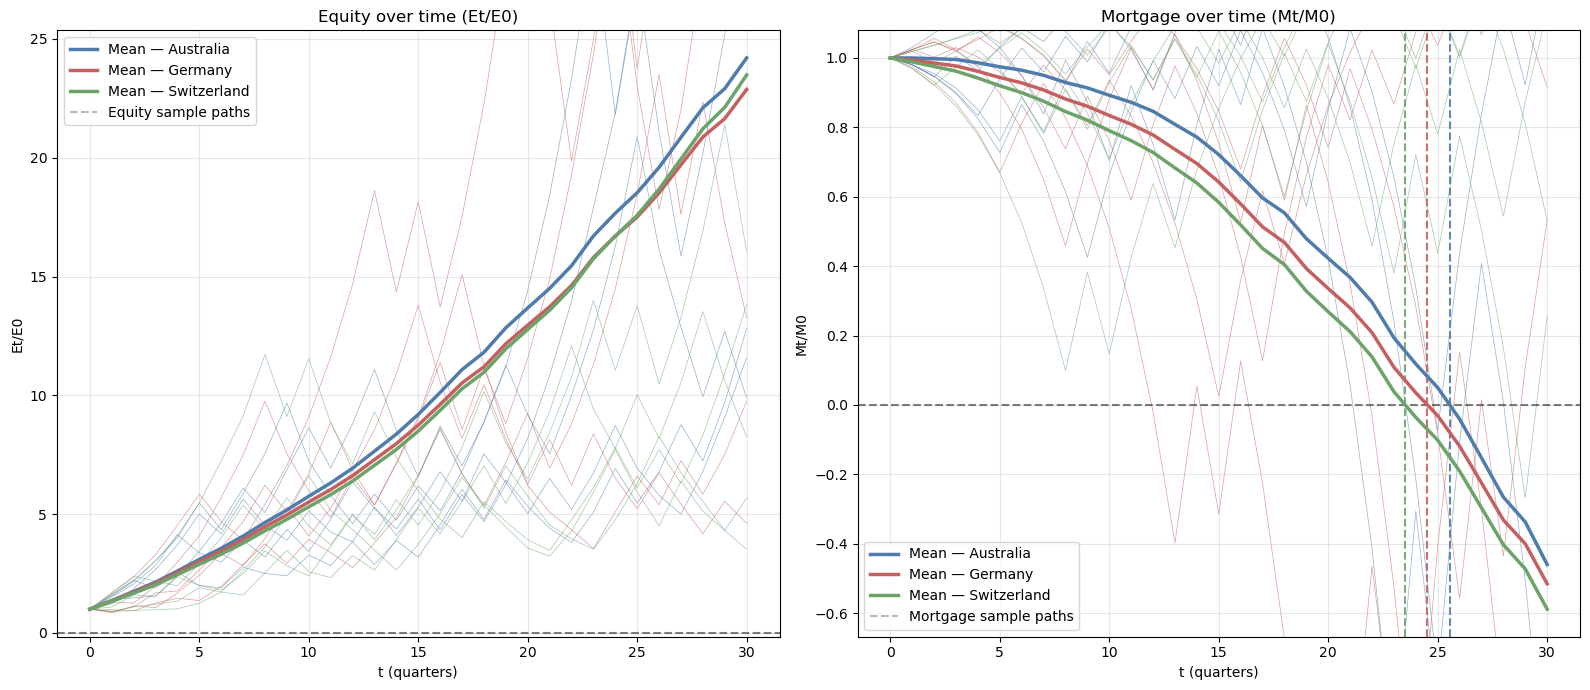

In [256]:


def plot_multi_scenario_trajectories():
    rng = np.random.default_rng(42)  # for reproducible path samples

    fig, (axE, axM) = plt.subplots(1, 2, figsize=(16, 7))
    axE.set_title('Equity over time (Et/E0)')
    axM.set_title('Mortgage over time (Mt/M0)')
    axE.set_xlabel('t (quarters)')
    axM.set_xlabel('t (quarters)')
    axE.set_ylabel('Et/E0')
    axM.set_ylabel('Mt/M0')
    for ax in (axE, axM):
        ax.grid(True, alpha=0.3)

    def _first_zero_crossing(time, y):
        # returns fractional t where y crosses from >0 to <=0; None if no crossing
        for i in range(1, len(y)):
            y0, y1 = y[i-1], y[i]
            if y0 == 0:          # exactly on grid
                return float(time[i-1])
            if (y0 > 0) and (y1 <= 0):
                t0, t1 = time[i-1], time[i]
                denom = (y0 - y1)
                frac = 1.0 if denom == 0 else max(0.0, min(1.0, y0/denom))
                return float(t0 + frac * (t1 - t0))
        return None

    # Track global y-limits across scenarios for consistent scaling
    e_lowers, e_uppers = [], []
    m_lowers, m_uppers = [], []

    # Collect legend handles
    legend_handles_E = []
    legend_handles_M = []
    sample_legend_added_E = False
    sample_legend_added_M = False

    time_grid_global = None  # assume same length across scenarios

    for sc in SCENARIOS:
        rb, rm, tb, tm = sc["rb"], sc["rm"], sc["tb"], sc["tm"]
        color = sc["color"]
        label = sc["label"]


        #  Run simulations for this scenario 
        (all_E, all_M, emp_mean_E, emp_mean_M,
         emp_std_E, emp_std_M, time_grid) = run_multiple_simulations(
            BASE_L, BASE_U, BASE_P, BASE_S,
            BASE_E0, BASE_M0,
            BASE_PI,                # deterministic payment value used by your simulator
            MAX_TIME, PHI, N_SIM,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        if time_grid_global is None:
            time_grid_global = time_grid

        # Normalize stats
        mean_E = emp_mean_E / BASE_E0
        mean_M = emp_mean_M / BASE_M0


        #  Plot mean trajectories (thick lines, scenario colors) 
        le, = axE.plot(time_grid, mean_E, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        lm, = axM.plot(time_grid, mean_M, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        legend_handles_E.append(le)
        legend_handles_M.append(lm)

        #   N_DISPLAY random individual paths (green/red) 
        # pick distinct indices
        n_avail = len(all_E)
        pick = rng.choice(n_avail, size=min(N_DISPLAY, n_avail), replace=False)
        for idx in pick:
            e_traj = np.asarray(all_E[idx]) / BASE_E0
            m_traj = np.asarray(all_M[idx]) / BASE_M0
            tt = np.arange(len(e_traj))
            # equity sample paths
            axE.plot(tt, e_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_E else None)
            # mortgage sample paths
            axM.plot(tt, m_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_M else None)

        if not sample_legend_added_E:
            sample_legend_added_E = True
        if not sample_legend_added_M:
            sample_legend_added_M = True

        #  first hitting time as vertical line per panel 
        if SHOW_HITTING:
            tE = _first_zero_crossing(time_grid, mean_E)
            if tE is not None and tE <= MAX_TIME:
                axE.axvline(tE, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

            tM = _first_zero_crossing(time_grid, mean_M)
            if tM is not None and tM <= MAX_TIME:
                axM.axvline(tM, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)


        # accumulate bounds for global y-lims
        e_lowers.append(np.nanmin(mean_E))
        e_uppers.append(np.nanmax(mean_E))
        m_lowers.append(np.nanmin(mean_M))
        m_uppers.append(np.nanmax(mean_M))

    # Consistent y-limits across scenarios
    def pad(lo, hi, frac=0.05):
        span = hi - lo
        return lo - frac*span, hi + frac*span

    e_lo, e_hi = pad(np.nanmin(e_lowers), np.nanmax(e_uppers))
    m_lo, m_hi = pad(np.nanmin(m_lowers), np.nanmax(m_uppers))
    axE.set_ylim(e_lo, e_hi)
    axM.set_ylim(m_lo, m_hi)

    # Zero lines
    axE.axhline(0.0, color='k', linestyle='--', alpha=0.5)
    axM.axhline(0.0, color='k', linestyle='--', alpha=0.5)

    # Legends
    # Add one legend entry explaining sample path colors
    sample_E = Line2D([0], [0], color='0.65', lw=1.5, alpha=0.8, linestyle='--', label='Equity sample paths')
    sample_M = Line2D([0], [0], color='0.65',   lw=1.5, alpha=0.8, linestyle='--', label='Mortgage sample paths')
    axE.legend(handles=legend_handles_E + [sample_E], loc='best')
    axM.legend(handles=legend_handles_M + [sample_M], loc='best')

    plt.tight_layout()
    plt.show()


plot_multi_scenario_trajectories()


## Country Default Scenario Self_owned

In [257]:
# Multi-scenario Monte Carlo setup 

# Base params 
BASE_L  = DEFAULT_PARAMS['l']
BASE_U  = DEFAULT_PARAMS['u']
BASE_P  = DEFAULT_PARAMS['p']
BASE_S  = DEFAULT_PARAMS['s']
BASE_E0 = DEFAULT_PARAMS['E0']
BASE_M0 = DEFAULT_PARAMS['M0']
BASE_PI = DEFAULT_PARAMS['pi_star']
BASE_Q  = DEFAULT_PARAMS['q']  

MAX_TIME     = 30          # quarters
PHI          = 0.01         # house-return shock std
N_SIM        = 1000         # Monte Carlo paths per scenario
N_DISPLAY    = 5            # number of individual paths to overlay
SHOW_HITTING = True         #  t* vertical lines (per panel) using classify_outcome

BASE_L  = 0.5
BASE_U  = 0.5
BASE_P  = 0.4 # 0.2
BASE_S  = -0.015 # -0.03
BASE_E0 = 30000
BASE_M0 = 300000
BASE_PI = 3000
BASE_Q  = 0.01

# Three scenarios – edit rb, rm, tb, tm here
SCENARIOS_annual = [
    {
        "label": "Australia",
        "rb": 0.0835, "rm": 0.0607, "tb": m_a, "tm": 0.0,
        "color": "#4F7CAC"  
    },
    {
        "label": "Germany",
        "rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": 0.0,
        "color": "#C65F5F"
    },
    {
        "label": "Switzerland",
        "rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s,
        "color": "#6BA368"
    }
]

SCENARIOS = [
    {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in scn.items()}
    for scn in SCENARIOS_annual
]

Running 1000 simulations... (rb=0.020251469359793717, rm=0.014841321609057934, tb=0.32, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.01309069972318655, rm=0.00910002891795858, tb=0.0, tm=0.0)
Completed 1000 simulations
Running 1000 simulations... (rb=0.004025626196972665, rm=0.004025626196972665, tb=0.2011999999999999, tm=0.2011999999999999)
Completed 1000 simulations


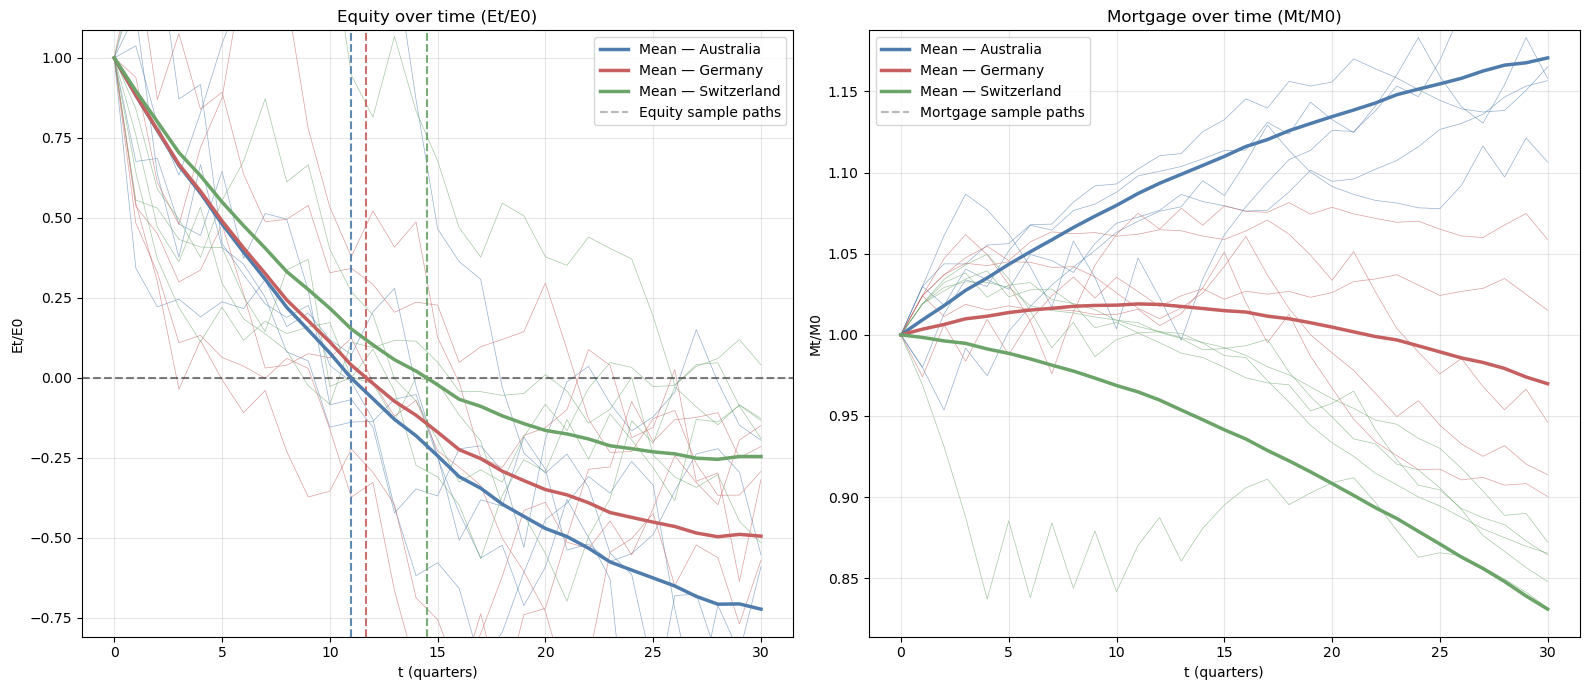

In [258]:


def plot_multi_scenario_trajectories():
    rng = np.random.default_rng(42)  # for reproducible path samples

    fig, (axE, axM) = plt.subplots(1, 2, figsize=(16, 7))
    axE.set_title('Equity over time (Et/E0)')
    axM.set_title('Mortgage over time (Mt/M0)')
    axE.set_xlabel('t (quarters)')
    axM.set_xlabel('t (quarters)')
    axE.set_ylabel('Et/E0')
    axM.set_ylabel('Mt/M0')
    for ax in (axE, axM):
        ax.grid(True, alpha=0.3)

    def _first_zero_crossing(time, y):
        # returns fractional t where y crosses from >0 to <=0; None if no crossing
        for i in range(1, len(y)):
            y0, y1 = y[i-1], y[i]
            if y0 == 0:          # exactly on grid
                return float(time[i-1])
            if (y0 > 0) and (y1 <= 0):
                t0, t1 = time[i-1], time[i]
                denom = (y0 - y1)
                frac = 1.0 if denom == 0 else max(0.0, min(1.0, y0/denom))
                return float(t0 + frac * (t1 - t0))
        return None

    # Track global y-limits across scenarios for consistent scaling
    e_lowers, e_uppers = [], []
    m_lowers, m_uppers = [], []

    # Collect legend handles
    legend_handles_E = []
    legend_handles_M = []
    sample_legend_added_E = False
    sample_legend_added_M = False

    time_grid_global = None  # assume same length across scenarios

    for sc in SCENARIOS:
        rb, rm, tb, tm = sc["rb"], sc["rm"], sc["tb"], sc["tm"]
        color = sc["color"]
        label = sc["label"]


        #  Run simulations for this scenario 
        (all_E, all_M, emp_mean_E, emp_mean_M,
         emp_std_E, emp_std_M, time_grid) = run_multiple_simulations(
            BASE_L, BASE_U, BASE_P, BASE_S,
            BASE_E0, BASE_M0,
            BASE_PI,                # deterministic payment value used by your simulator
            MAX_TIME, PHI, N_SIM,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        if time_grid_global is None:
            time_grid_global = time_grid

        # Normalize stats
        mean_E = emp_mean_E / BASE_E0
        mean_M = emp_mean_M / BASE_M0


        #  Plot mean trajectories (thick lines, scenario colors) 
        le, = axE.plot(time_grid, mean_E, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        lm, = axM.plot(time_grid, mean_M, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        legend_handles_E.append(le)
        legend_handles_M.append(lm)

        #   N_DISPLAY random individual paths (green/red) 
        # pick distinct indices
        n_avail = len(all_E)
        pick = rng.choice(n_avail, size=min(N_DISPLAY, n_avail), replace=False)
        for idx in pick:
            e_traj = np.asarray(all_E[idx]) / BASE_E0
            m_traj = np.asarray(all_M[idx]) / BASE_M0
            tt = np.arange(len(e_traj))
            # equity sample paths
            axE.plot(tt, e_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_E else None)
            # mortgage sample paths
            axM.plot(tt, m_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_M else None)

        if not sample_legend_added_E:
            sample_legend_added_E = True
        if not sample_legend_added_M:
            sample_legend_added_M = True

        #  first hitting time as vertical line per panel 
        if SHOW_HITTING:
            tE = _first_zero_crossing(time_grid, mean_E)
            if tE is not None and tE <= MAX_TIME:
                axE.axvline(tE, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

            tM = _first_zero_crossing(time_grid, mean_M)
            if tM is not None and tM <= MAX_TIME:
                axM.axvline(tM, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)


        # accumulate bounds for global y-lims
        e_lowers.append(np.nanmin(mean_E))
        e_uppers.append(np.nanmax(mean_E))
        m_lowers.append(np.nanmin(mean_M))
        m_uppers.append(np.nanmax(mean_M))

    # Consistent y-limits across scenarios
    def pad(lo, hi, frac=0.05):
        span = hi - lo
        return lo - frac*span, hi + frac*span

    e_lo, e_hi = pad(np.nanmin(e_lowers), np.nanmax(e_uppers))
    m_lo, m_hi = pad(np.nanmin(m_lowers), np.nanmax(m_uppers))
    axE.set_ylim(e_lo, e_hi)
    axM.set_ylim(m_lo, m_hi)

    # Zero lines
    axE.axhline(0.0, color='k', linestyle='--', alpha=0.5)
    axM.axhline(0.0, color='k', linestyle='--', alpha=0.5)

    # Legends
    # Add one legend entry explaining sample path colors
    sample_E = Line2D([0], [0], color='0.65', lw=1.5, alpha=0.8, linestyle='--', label='Equity sample paths')
    sample_M = Line2D([0], [0], color='0.65',   lw=1.5, alpha=0.8, linestyle='--', label='Mortgage sample paths')
    axE.legend(handles=legend_handles_E + [sample_E], loc='best')
    axM.legend(handles=legend_handles_M + [sample_M], loc='best')

    plt.tight_layout()
    plt.show()


plot_multi_scenario_trajectories()


## Country Default Scenario Rental

In [275]:
# Multi-scenario Monte Carlo setup

# Base params 
BASE_L  = DEFAULT_PARAMS['l']
BASE_U  = DEFAULT_PARAMS['u']
BASE_P  = DEFAULT_PARAMS['p']
BASE_S  = DEFAULT_PARAMS['s']
BASE_E0 = DEFAULT_PARAMS['E0']
BASE_M0 = DEFAULT_PARAMS['M0']
BASE_PI = DEFAULT_PARAMS['pi_star']
BASE_Q  = DEFAULT_PARAMS['q']  

MAX_TIME     = 30          # quarters
PHI          = 0.01         # house-return shock std
N_SIM        = 1000         # Monte Carlo paths per scenario
N_DISPLAY    = 5            # number of individual paths to overlay
SHOW_HITTING = True         #  t* vertical lines (per panel) using classify_outcome

BASE_L  = 0.5
BASE_U  = 0.5
BASE_P  = 0.4
BASE_S  = -0.015
BASE_E0 = 30000
BASE_M0 = 300000
BASE_PI = 3000
BASE_Q  = 0.01

# Three scenarios – edit rb, rm, tb, tm here
SCENARIOS_annual = [
    {
        "label": "Australia",
        "rb": 0.0835, "rm": 0.0628, "tb": m_a, "tm": m_a,
        "color": "#4F7CAC"  
    },
    {
        "label": "Germany",
        "rb": 0.0534, "rm": 0.0369, "tb": 0.0, "tm": m_g,
        "color": "#C65F5F"
    },
    {
        "label": "Switzerland",
        "rb": 0.0162, "rm": 0.0162, "tb": m_s, "tm": m_s,
        "color": "#6BA368"
    }
]

SCENARIOS = [
    {k: (r_to_quarter(v) if k in ["rb", "rm"] else v) for k, v in scn.items()}
    for scn in SCENARIOS_annual
]

Running 1000 simulations... (rb=0.020251469359793717, rm=0.015343251077580167, tb=0.32, tm=0.32)
Completed 1000 simulations
Running 1000 simulations... (rb=0.01309069972318655, rm=0.00910002891795858, tb=0.0, tm=0.374529312)
Completed 1000 simulations
Running 1000 simulations... (rb=0.004025626196972665, rm=0.004025626196972665, tb=0.2011999999999999, tm=0.2011999999999999)
Completed 1000 simulations


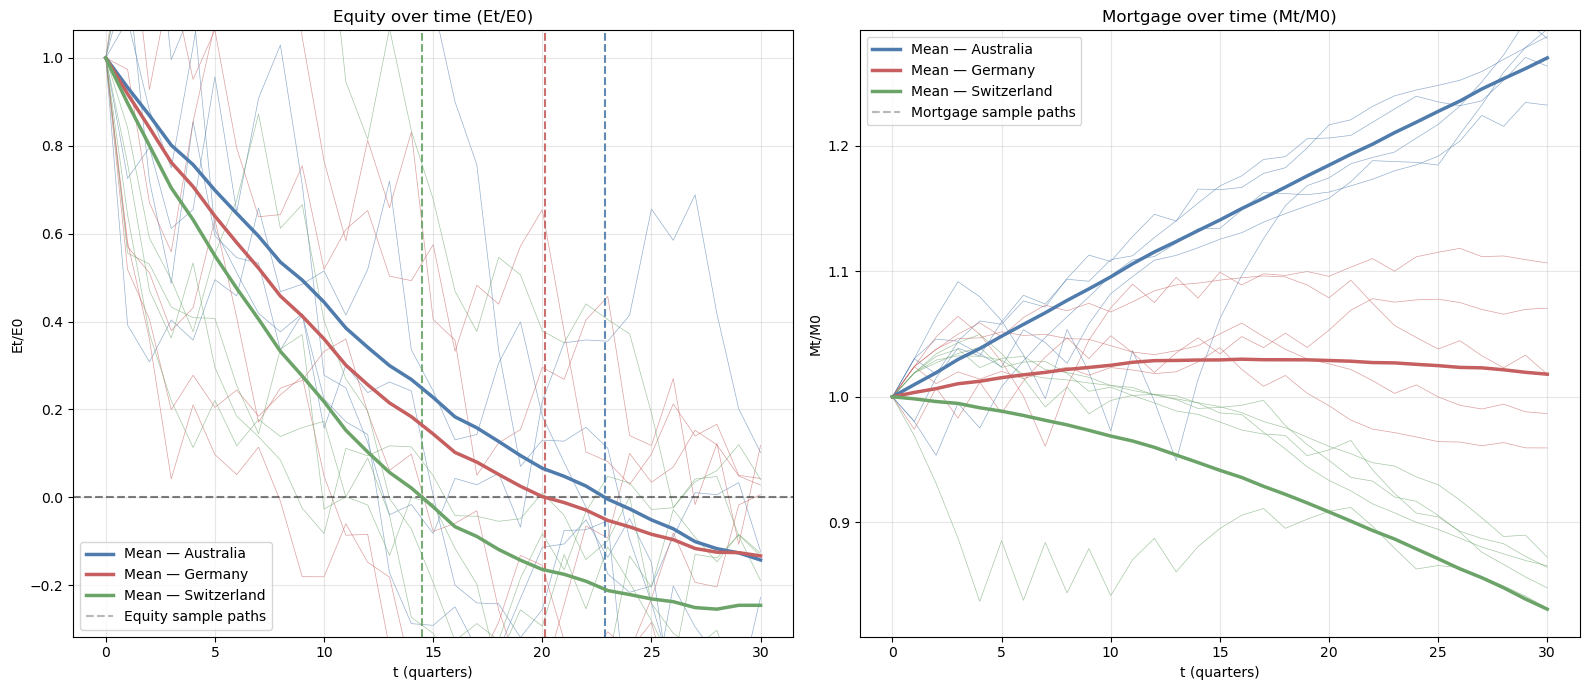

In [276]:


def plot_multi_scenario_trajectories():
    rng = np.random.default_rng(42)  # for reproducible path samples

    fig, (axE, axM) = plt.subplots(1, 2, figsize=(16, 7))
    axE.set_title('Equity over time (Et/E0)')
    axM.set_title('Mortgage over time (Mt/M0)')
    axE.set_xlabel('t (quarters)')
    axM.set_xlabel('t (quarters)')
    axE.set_ylabel('Et/E0')
    axM.set_ylabel('Mt/M0')
    for ax in (axE, axM):
        ax.grid(True, alpha=0.3)

    def _first_zero_crossing(time, y):
        # returns fractional t where y crosses from >0 to <=0; None if no crossing
        for i in range(1, len(y)):
            y0, y1 = y[i-1], y[i]
            if y0 == 0:          # exactly on grid
                return float(time[i-1])
            if (y0 > 0) and (y1 <= 0):
                t0, t1 = time[i-1], time[i]
                denom = (y0 - y1)
                frac = 1.0 if denom == 0 else max(0.0, min(1.0, y0/denom))
                return float(t0 + frac * (t1 - t0))
        return None

    # Track global y-limits across scenarios for consistent scaling
    e_lowers, e_uppers = [], []
    m_lowers, m_uppers = [], []

    # Collect legend handles
    legend_handles_E = []
    legend_handles_M = []
    sample_legend_added_E = False
    sample_legend_added_M = False

    time_grid_global = None  # assume same length across scenarios

    for sc in SCENARIOS:
        rb, rm, tb, tm = sc["rb"], sc["rm"], sc["tb"], sc["tm"]
        color = sc["color"]
        label = sc["label"]


        #  Run simulations for this scenario 
        (all_E, all_M, emp_mean_E, emp_mean_M,
         emp_std_E, emp_std_M, time_grid) = run_multiple_simulations(
            BASE_L, BASE_U, BASE_P, BASE_S,
            BASE_E0, BASE_M0,
            BASE_PI,                # deterministic payment value used by your simulator
            MAX_TIME, PHI, N_SIM,
            rb=rb, rm=rm, tb=tb, tm=tm
        )

        if time_grid_global is None:
            time_grid_global = time_grid

        # Normalize stats
        mean_E = emp_mean_E / BASE_E0
        mean_M = emp_mean_M / BASE_M0


        #  Plot mean trajectories (thick lines, scenario colors) 
        le, = axE.plot(time_grid, mean_E, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        lm, = axM.plot(time_grid, mean_M, color=color, linewidth=2.5, zorder=3, label=f'Mean — {label}')
        legend_handles_E.append(le)
        legend_handles_M.append(lm)

        #   N_DISPLAY random individual paths (green/red) 
        # pick distinct indices
        n_avail = len(all_E)
        pick = rng.choice(n_avail, size=min(N_DISPLAY, n_avail), replace=False)
        for idx in pick:
            e_traj = np.asarray(all_E[idx]) / BASE_E0
            m_traj = np.asarray(all_M[idx]) / BASE_M0
            tt = np.arange(len(e_traj))
            # equity sample paths
            axE.plot(tt, e_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_E else None)
            # mortgage sample paths
            axM.plot(tt, m_traj, color=color, alpha=0.6, linewidth=0.5, zorder=1,
                     label='sample path' if not sample_legend_added_M else None)

        if not sample_legend_added_E:
            sample_legend_added_E = True
        if not sample_legend_added_M:
            sample_legend_added_M = True

        #  first hitting time as vertical line per panel 
        if SHOW_HITTING:
            tE = _first_zero_crossing(time_grid, mean_E)
            if tE is not None and tE <= MAX_TIME:
                axE.axvline(tE, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

            tM = _first_zero_crossing(time_grid, mean_M)
            if tM is not None and tM <= MAX_TIME:
                axM.axvline(tM, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)


        # accumulate bounds for global y-lims
        e_lowers.append(np.nanmin(mean_E))
        e_uppers.append(np.nanmax(mean_E))
        m_lowers.append(np.nanmin(mean_M))
        m_uppers.append(np.nanmax(mean_M))

    # Consistent y-limits across scenarios
    def pad(lo, hi, frac=0.05):
        span = hi - lo
        return lo - frac*span, hi + frac*span

    e_lo, e_hi = pad(np.nanmin(e_lowers), np.nanmax(e_uppers))
    m_lo, m_hi = pad(np.nanmin(m_lowers), np.nanmax(m_uppers))
    axE.set_ylim(e_lo, e_hi)
    axM.set_ylim(m_lo, m_hi)

    # Zero lines
    axE.axhline(0.0, color='k', linestyle='--', alpha=0.5)
    axM.axhline(0.0, color='k', linestyle='--', alpha=0.5)

    # Legends
    # Add one legend entry explaining sample path colors
    sample_E = Line2D([0], [0], color='0.65', lw=1.5, alpha=0.8, linestyle='--', label='Equity sample paths')
    sample_M = Line2D([0], [0], color='0.65',   lw=1.5, alpha=0.8, linestyle='--', label='Mortgage sample paths')
    axE.legend(handles=legend_handles_E + [sample_E], loc='best')
    axM.legend(handles=legend_handles_M + [sample_M], loc='best')

    plt.tight_layout()
    plt.show()


plot_multi_scenario_trajectories()
